# Self Learning

1. see the dft data as unlabeled data, and then we use the xgboost model which trained on exp set to label the dft data.
2. discard items that differ significantly(**Δ>1**) between exp model prediction and dft calculation.
3. use the labeled dft data and exp data together to train model and then label the dft data again.
4. Repeat the above steps.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
np.random.seed(42)
current_path = os.getcwd()
current_path

'c:\\Users\\Fortyfour\\Desktop\\graduation_design\\Scripts_git\\MixedDataTrain'

In [2]:
file_path = os.path.join(current_path, 'SelfLearning')
os.makedirs(file_path, exist_ok=True)

In [3]:
# Set random seed for reproducibility
RANDOM_SEED = 42
# 
FIG_SHOW = False


In [4]:
# To import the custom module from a specific path
sys.path.insert(0, os.path.join(current_path, '../'))
# Importing the custom module
from Utools.SingleModel import SingleModel

In [18]:
# Load data
file_dir = os.path.join(current_path, '../Data/composition_data/feature_data')
# dft data
dft_train = pd.read_csv(os.path.join(file_dir, 'dft', 'train.csv'))
dft_test = pd.read_csv(os.path.join(file_dir, 'dft', 'test.csv'))
# exp data
exp_train = pd.read_csv(os.path.join(file_dir, 'exp', 'train.csv'))
exp_test = pd.read_csv(os.path.join(file_dir, 'exp', 'test.csv'))

dft_train_X = dft_train.drop(columns=['composition', 'band_gap'])
dft_train_y = dft_train['band_gap']
exp_train_X = exp_train.drop(columns=['composition', 'band_gap'])
exp_train_y = exp_train['band_gap']
dft_test_X = dft_test.drop(columns=['composition', 'band_gap'])
dft_test_y = dft_test['band_gap']
exp_test_X = exp_test.drop(columns=['composition', 'band_gap'])
exp_test_y = exp_test['band_gap']


# Mixed test set
# due to the number of test samples in dft and exp have a large difference
# so we resample the dft test set:   dft:exp = 2:1
dft_test_X_subset = dft_test_X.sample(n=round(len(exp_test_X) * 2), random_state=RANDOM_SEED)
dft_test_y_subset = dft_test_y.loc[dft_test_X_subset.index]
# mix
test_X = pd.concat([dft_test_X_subset, exp_test_X], ignore_index=True)
test_y = pd.concat([dft_test_y_subset, exp_test_y], ignore_index=True)

In [6]:
dft_train_X.shape, exp_train_X.shape, test_X.shape, test_y.shape

((22220, 132), (3025, 132), (2271, 132), (2271,))

In [7]:
from xgboost import XGBRegressor
from sklearn.base import clone

In [8]:
xgb = XGBRegressor(learning_rate=0.1, max_depth=5, n_estimators=500,
    colsample_bytree=0.7, subsample=0.9, reg_lambda=0.5, alpha=0.5,
    objective='reg:squarederror', random_state=RANDOM_SEED, n_jobs=-1)
exp_model = SingleModel(clone(xgb), random_state=RANDOM_SEED)
exp_model.train(exp_train_X, exp_train_y)

Starting model training...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............. (step 2 of 2) Processing model, total=   1.6s
Model training completed!


In [24]:
# 1. total dft train data 
self_learn_model = exp_model
eventually_model = None
# 
LARGE_ERROR = 1.1
SMALL_ERROR_RATE = 0.95
EXP_RATIO = 0.5
# track
iteration_metrics = []  

for i in range(100):
    pred_y = self_learn_model.predict(dft_train_X)

    # discard the samples with large error
    # get the samples with small error  
    small_error_index = (np.abs(pred_y - dft_train_y) <= LARGE_ERROR)
    small_error_X = dft_train_X[small_error_index]
    # 
    small_error_y = (pred_y[small_error_index]*EXP_RATIO) + (dft_train_y[small_error_index]*(1-EXP_RATIO))

    # 
    if small_error_X.shape[0] > SMALL_ERROR_RATE*len(dft_train_X):
        print('The number of small error samples is greater than the threshold.')
        eventually_model = self_learn_model
        break
    # log
    print(f'[ Iteration {i} ]: ')
    print(f'small error samples: {small_error_X.shape[0]}')
    # save metrics
    test_metrics = self_learn_model.evaluate(test_X, test_y, fig_show=False)
    iteration_metrics.append({
        'iteration': i,
        'small_error_samples': small_error_X.shape[0],
        'test_r2': test_metrics['r2'],
        'test_rmse': test_metrics['rmse']
    })

    # early stopping
    if i > 0 and iteration_metrics[-1]['test_rmse'] >= iteration_metrics[-2]['test_rmse']:
        consecutive_no_improvement += 1
    else:
        consecutive_no_improvement = 0

    if consecutive_no_improvement >= 3:
        print(f"Early stopping at iteration {i} due to no improvement")
        eventually_model = self_learn_model
        break

    # train the model on the small error samples and exp samples
    train_X = pd.concat([small_error_X, exp_train_X], axis=0, ignore_index=True)
    train_y = pd.concat([small_error_y, exp_train_y], axis=0, ignore_index=True)

    self_learn_model = SingleModel(clone(xgb), random_state=RANDOM_SEED)
    self_learn_model.train(train_X, train_y)

if eventually_model is None:
    eventually_model = self_learn_model


[ Iteration 0 ]: 
small error samples: 14801

Model Evaluation Results:
Test set size: 2271
Test set: R²: 0.4504 RMSE: 1.0250 MAE: 0.7125 MAPE: 208.4920%
Starting model training...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............. (step 2 of 2) Processing model, total=   2.3s
Model training completed!
[ Iteration 1 ]: 
small error samples: 16844

Model Evaluation Results:
Test set size: 2271
Test set: R²: 0.5825 RMSE: 0.8934 MAE: 0.6073 MAPE: 187.7406%
Starting model training...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............. (step 2 of 2) Processing model, total=   2.6s
Model training completed!
[ Iteration 2 ]: 
small error samples: 17795

Model Evaluation Results:
Test set size: 2271
Test set: R²: 0.6352 RMSE: 0.8350 MAE: 0.5573 MAPE: 178.5288%
Starting model training...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............. (step 2 of 2) Processing 

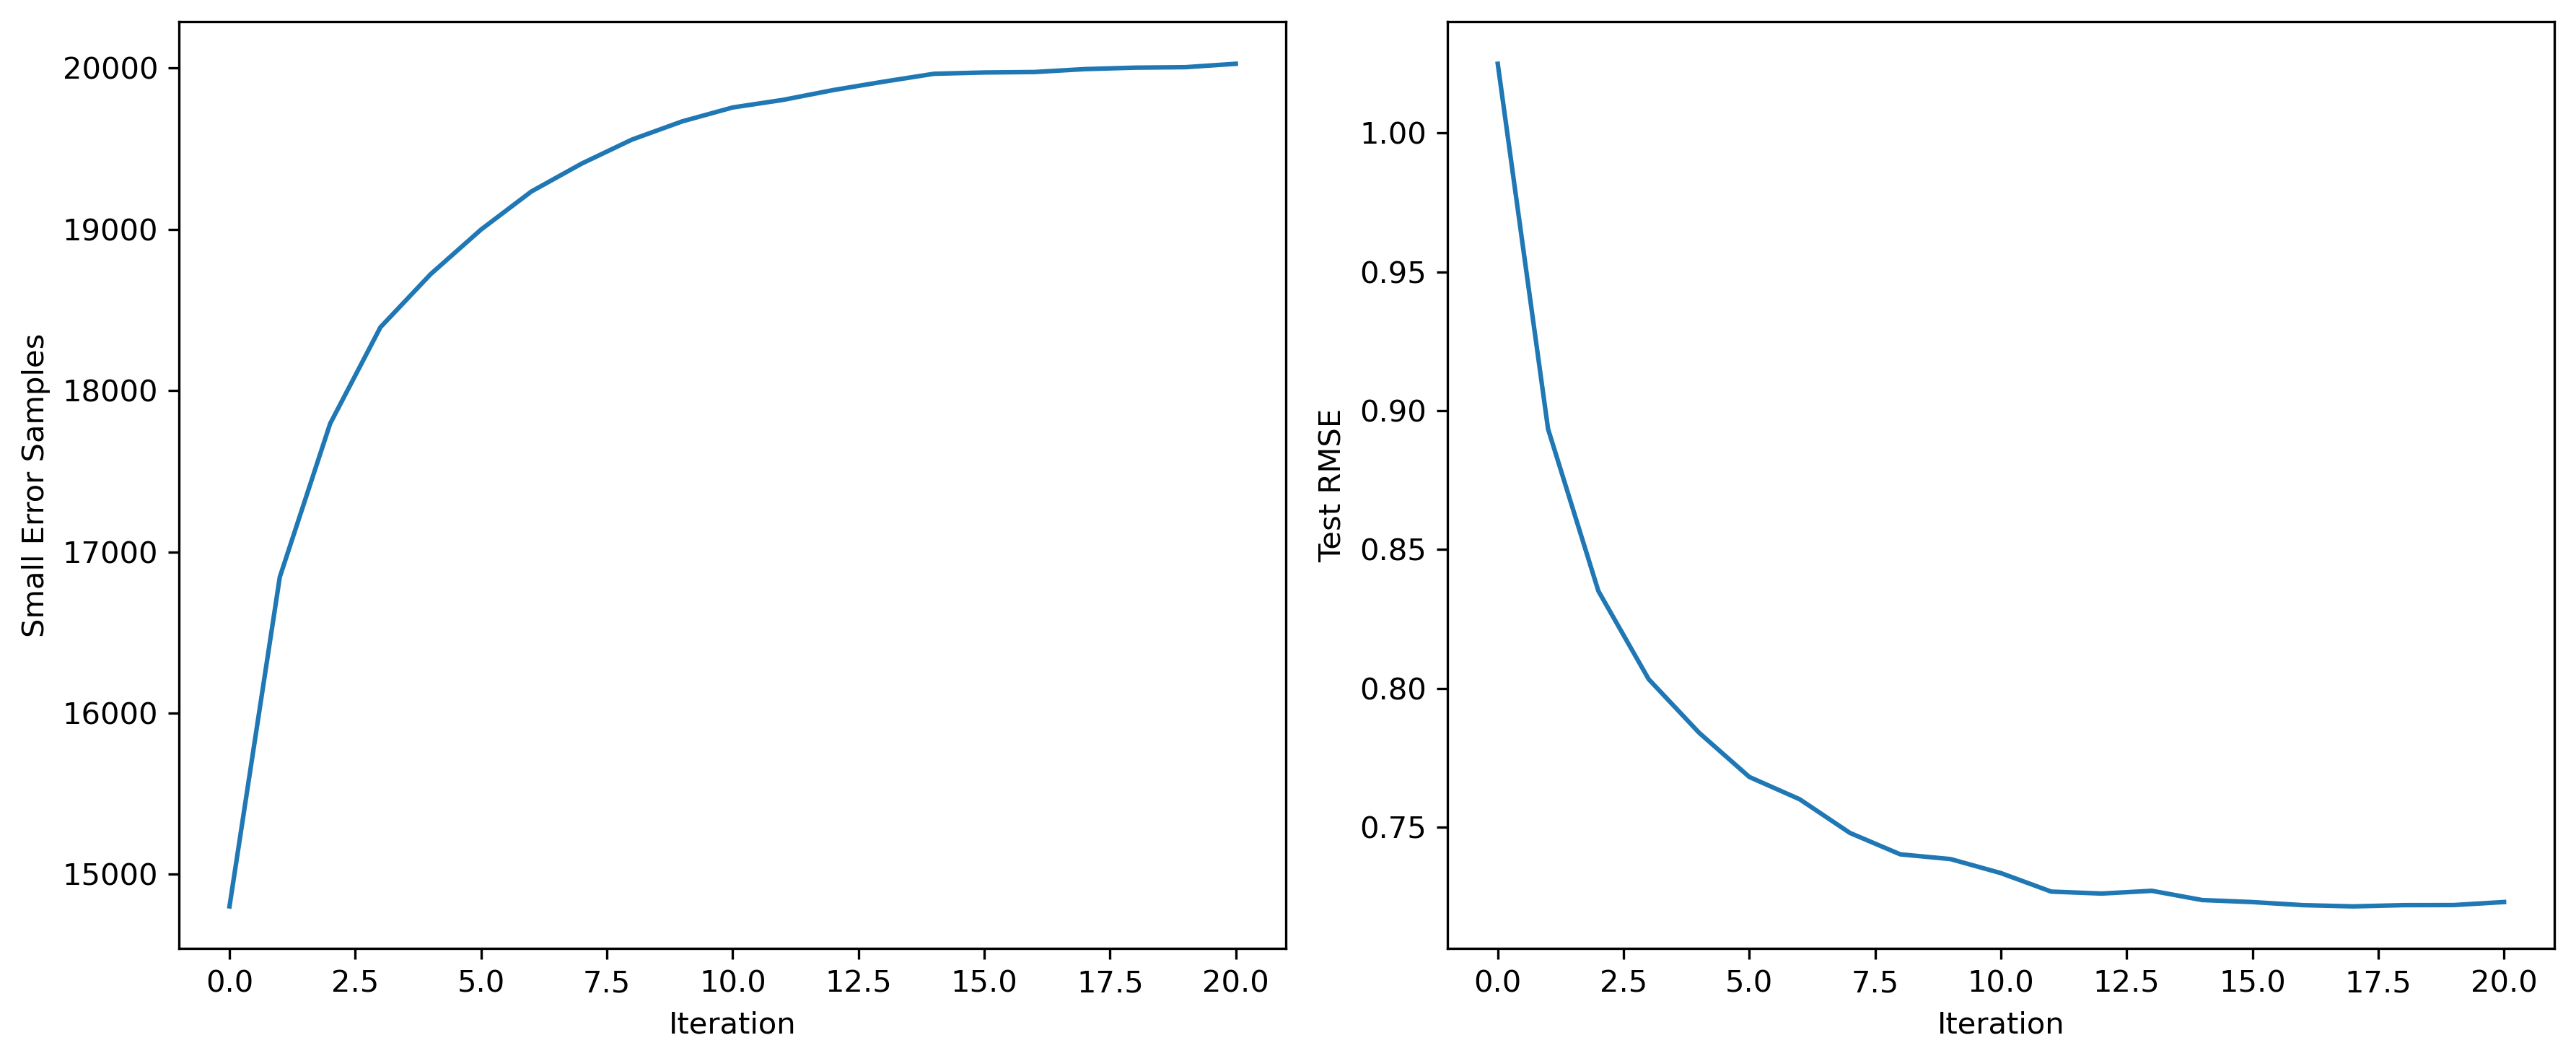

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5), dpi=300)
plt.subplot(1, 2, 1)
plt.plot([m['iteration'] for m in iteration_metrics], 
         [m['small_error_samples'] for m in iteration_metrics])
plt.xlabel('Iteration')
plt.ylabel('Small Error Samples')
plt.subplot(1, 2, 2)
plt.plot([m['iteration'] for m in iteration_metrics], 
         [m['test_rmse'] for m in iteration_metrics])
plt.xlabel('Iteration')
plt.ylabel('Test RMSE')
plt.tight_layout()
plt.savefig(os.path.join(file_path, 'iteration_metrics.png'))

####################################################################################################
[DFT - Self Learning XGBoost] Training Self Learning XGBoost on Mix data:
----------------------------------------------------------------------------------------------------
[Train_error] Evaluating Self Learning XGBoost on train set:


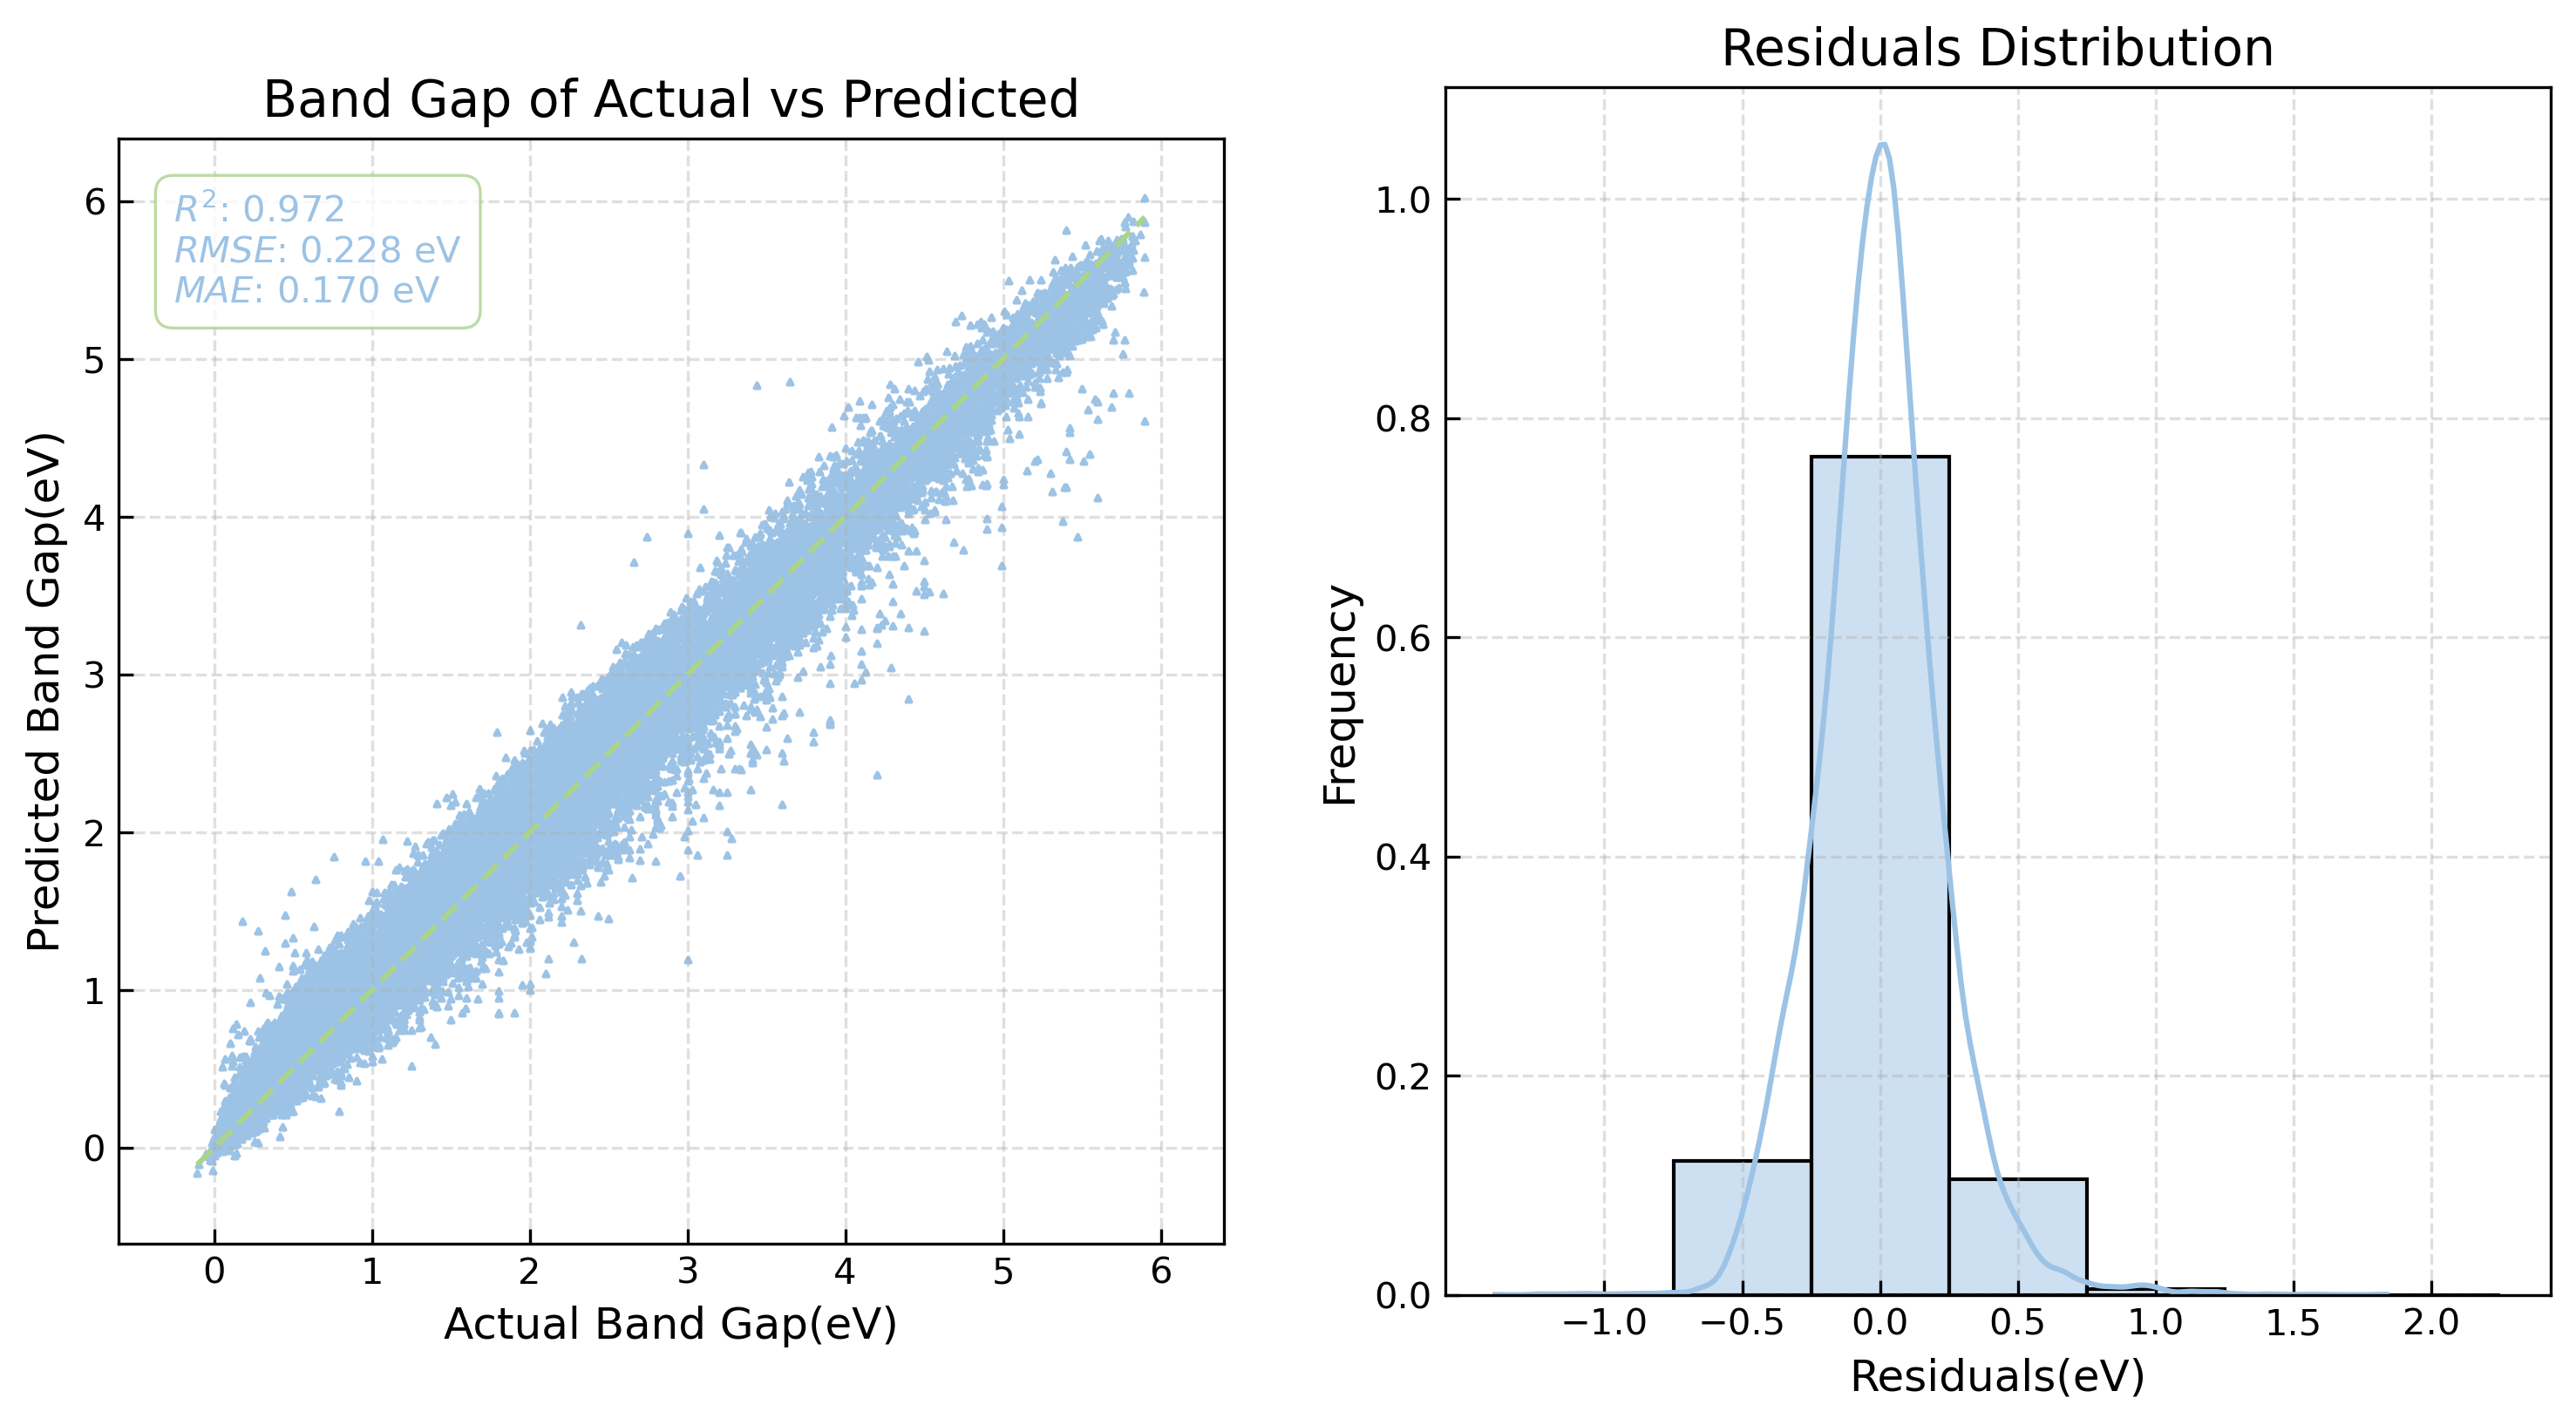


Model Evaluation Results:
Test set size: 23031
Test set: R²: 0.9715 RMSE: 0.2283 MAE: 0.1704 MAPE: 13.4333%
[Test MIX -> DFT] Evaluating Self Learning XGBoost on DFT test set:


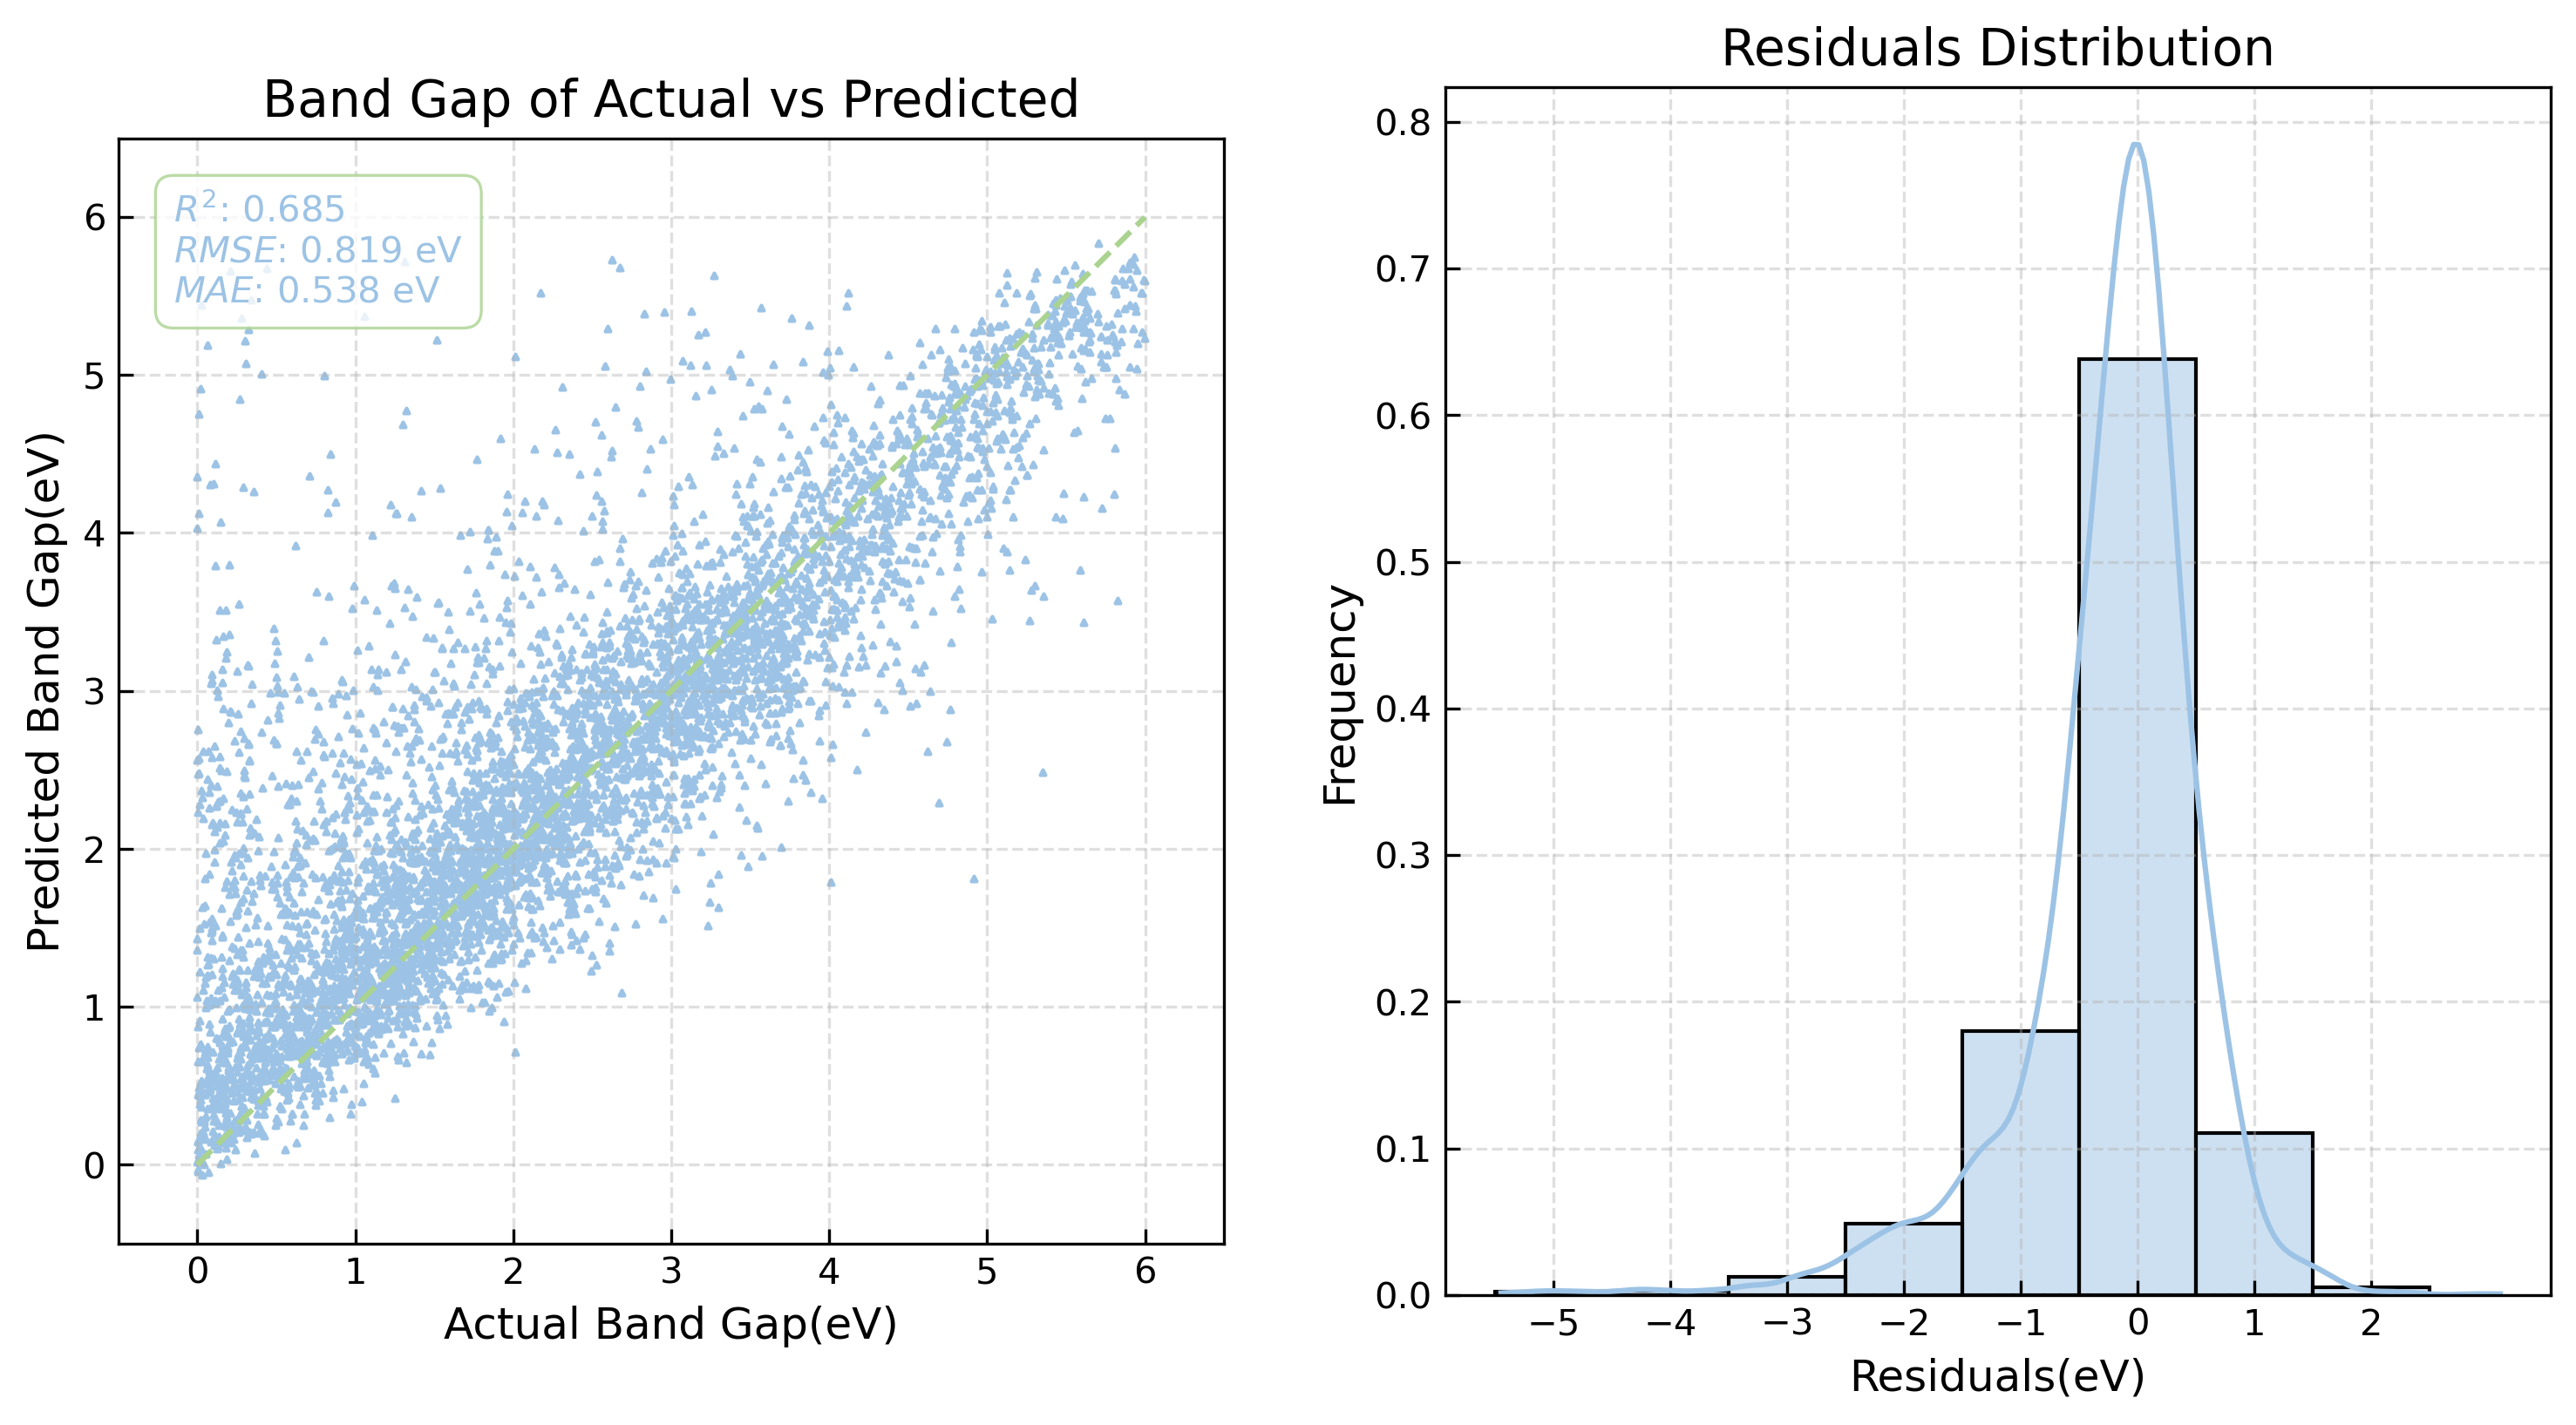


Model Evaluation Results:
Test set size: 5556
Test set: R²: 0.6855 RMSE: 0.8193 MAE: 0.5381 MAPE: 1996.5051%
[Test MIX -> EXP] Evaluating Self Learning XGBoost on EXP test set:


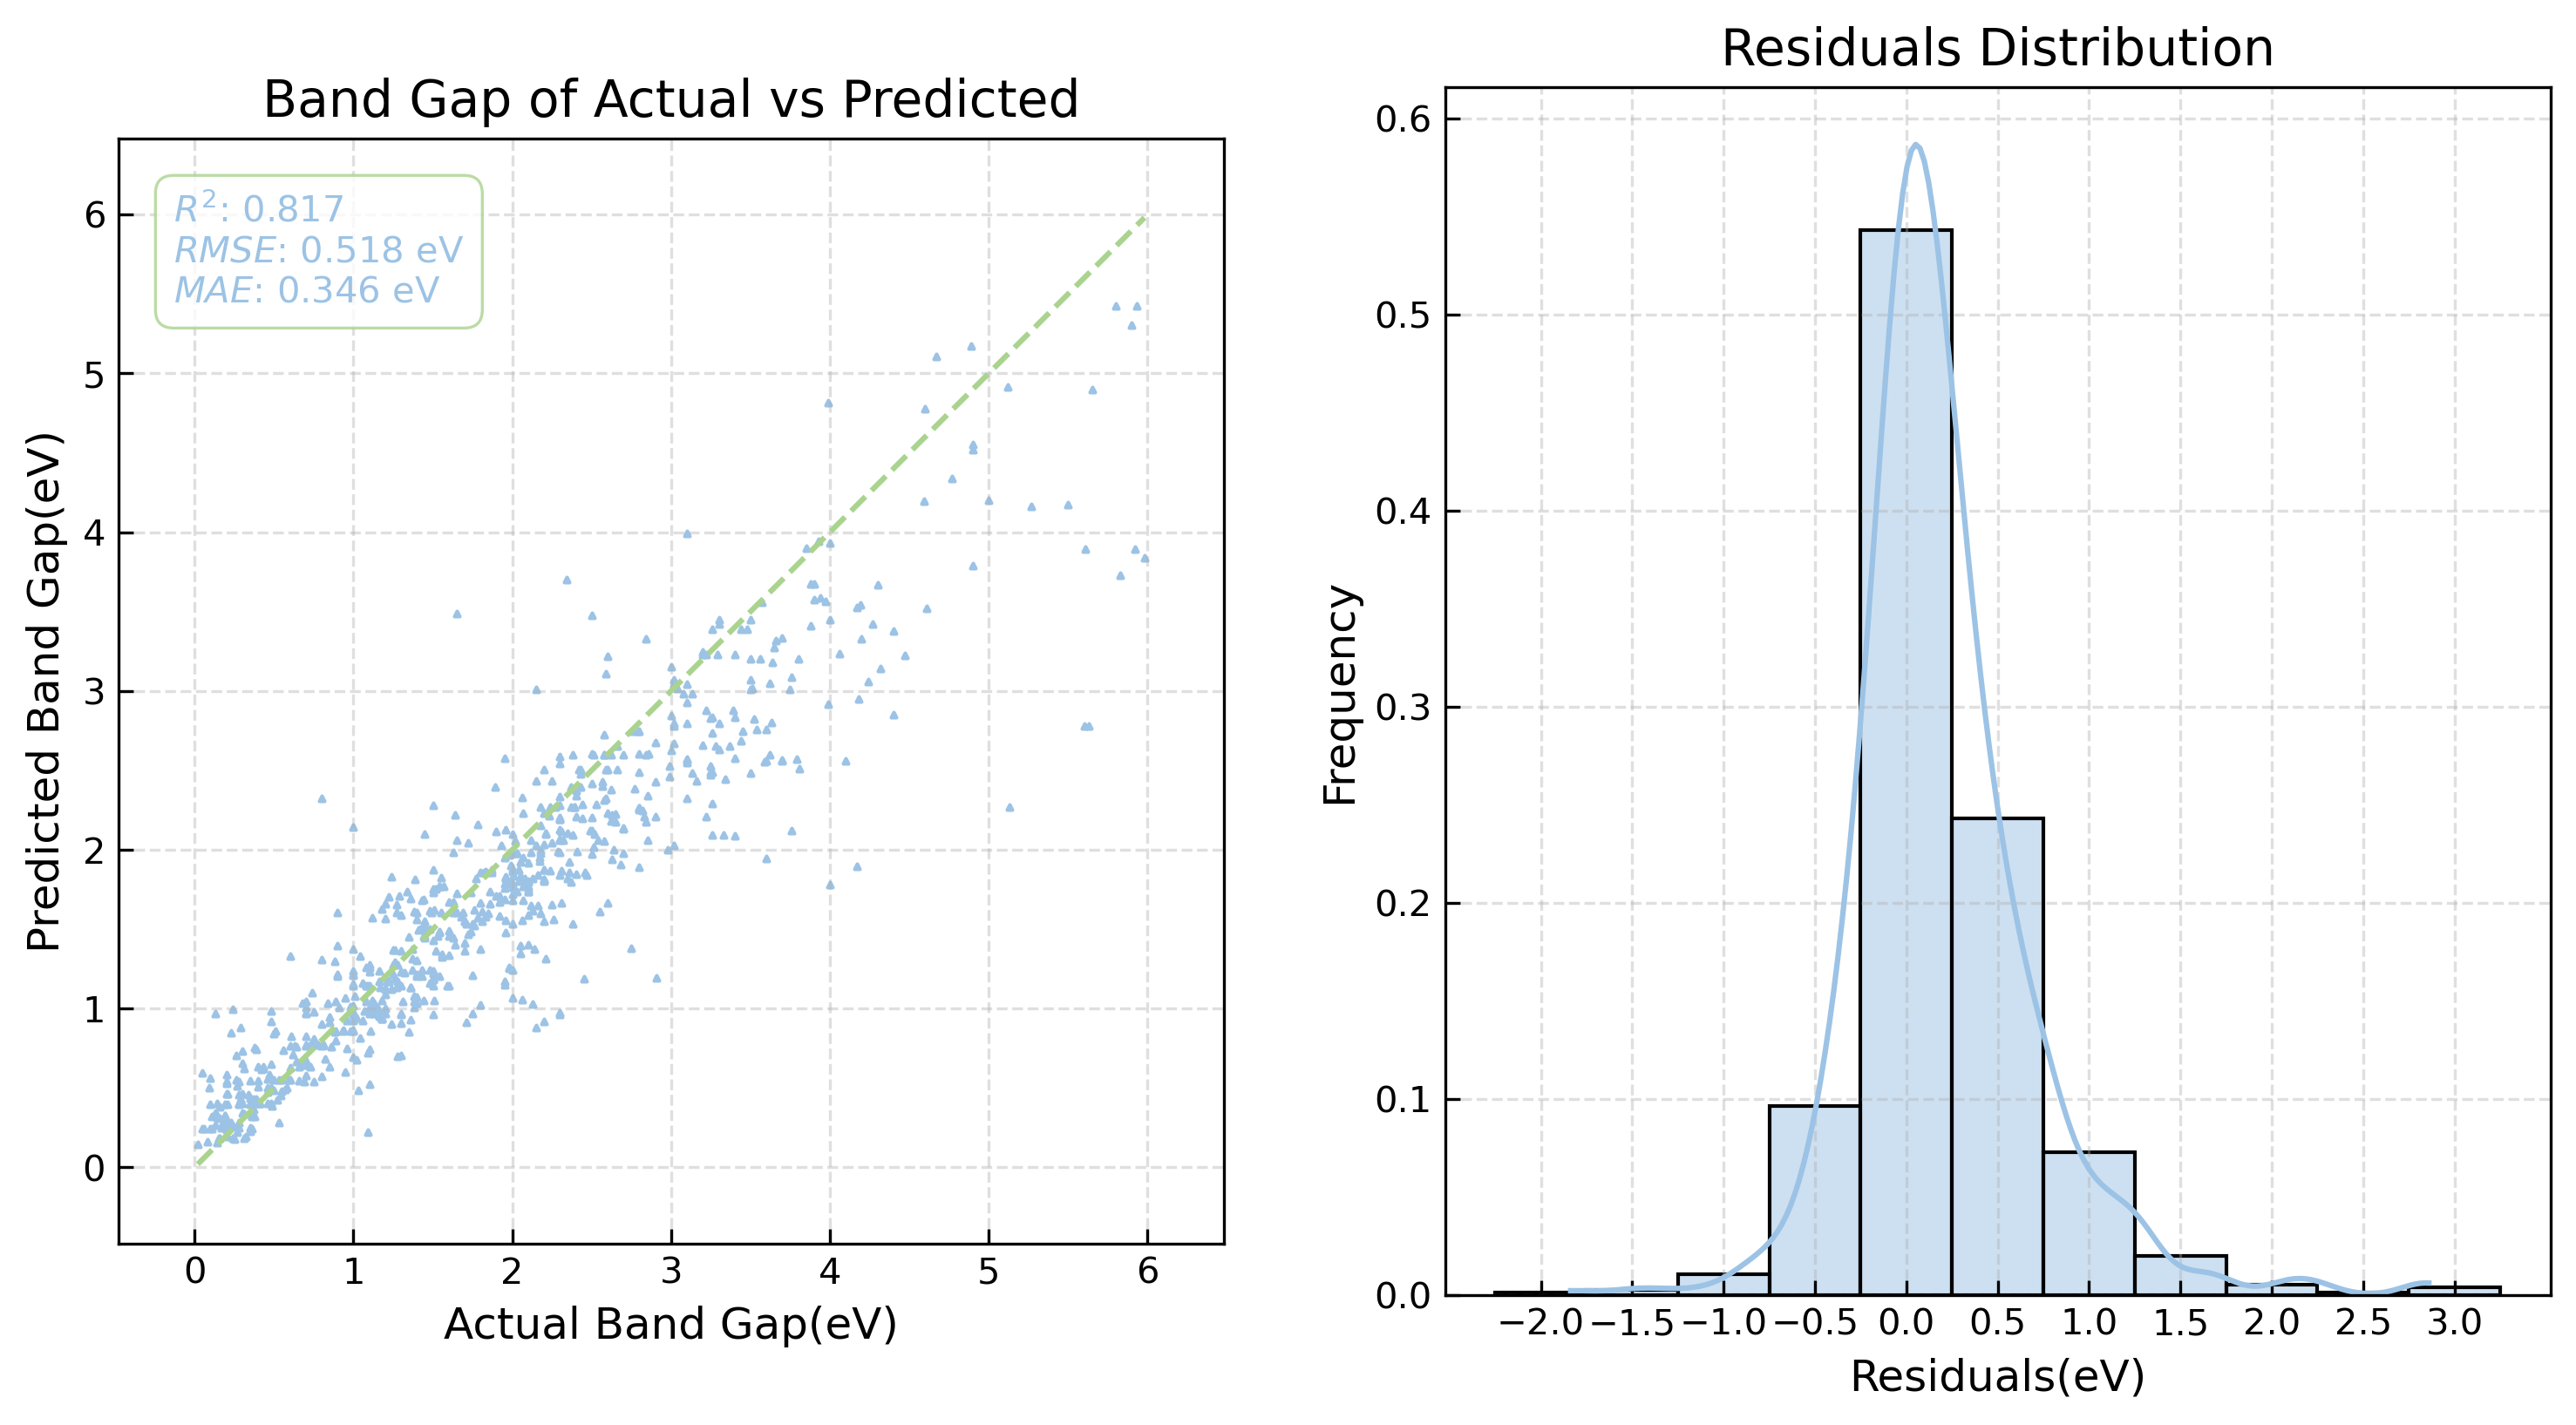


Model Evaluation Results:
Test set size: 757
Test set: R²: 0.8169 RMSE: 0.5183 MAE: 0.3463 MAPE: 29.0351%
[Test MIX -> MIX] Evaluating Self Learning XGBoost on mixed test set:


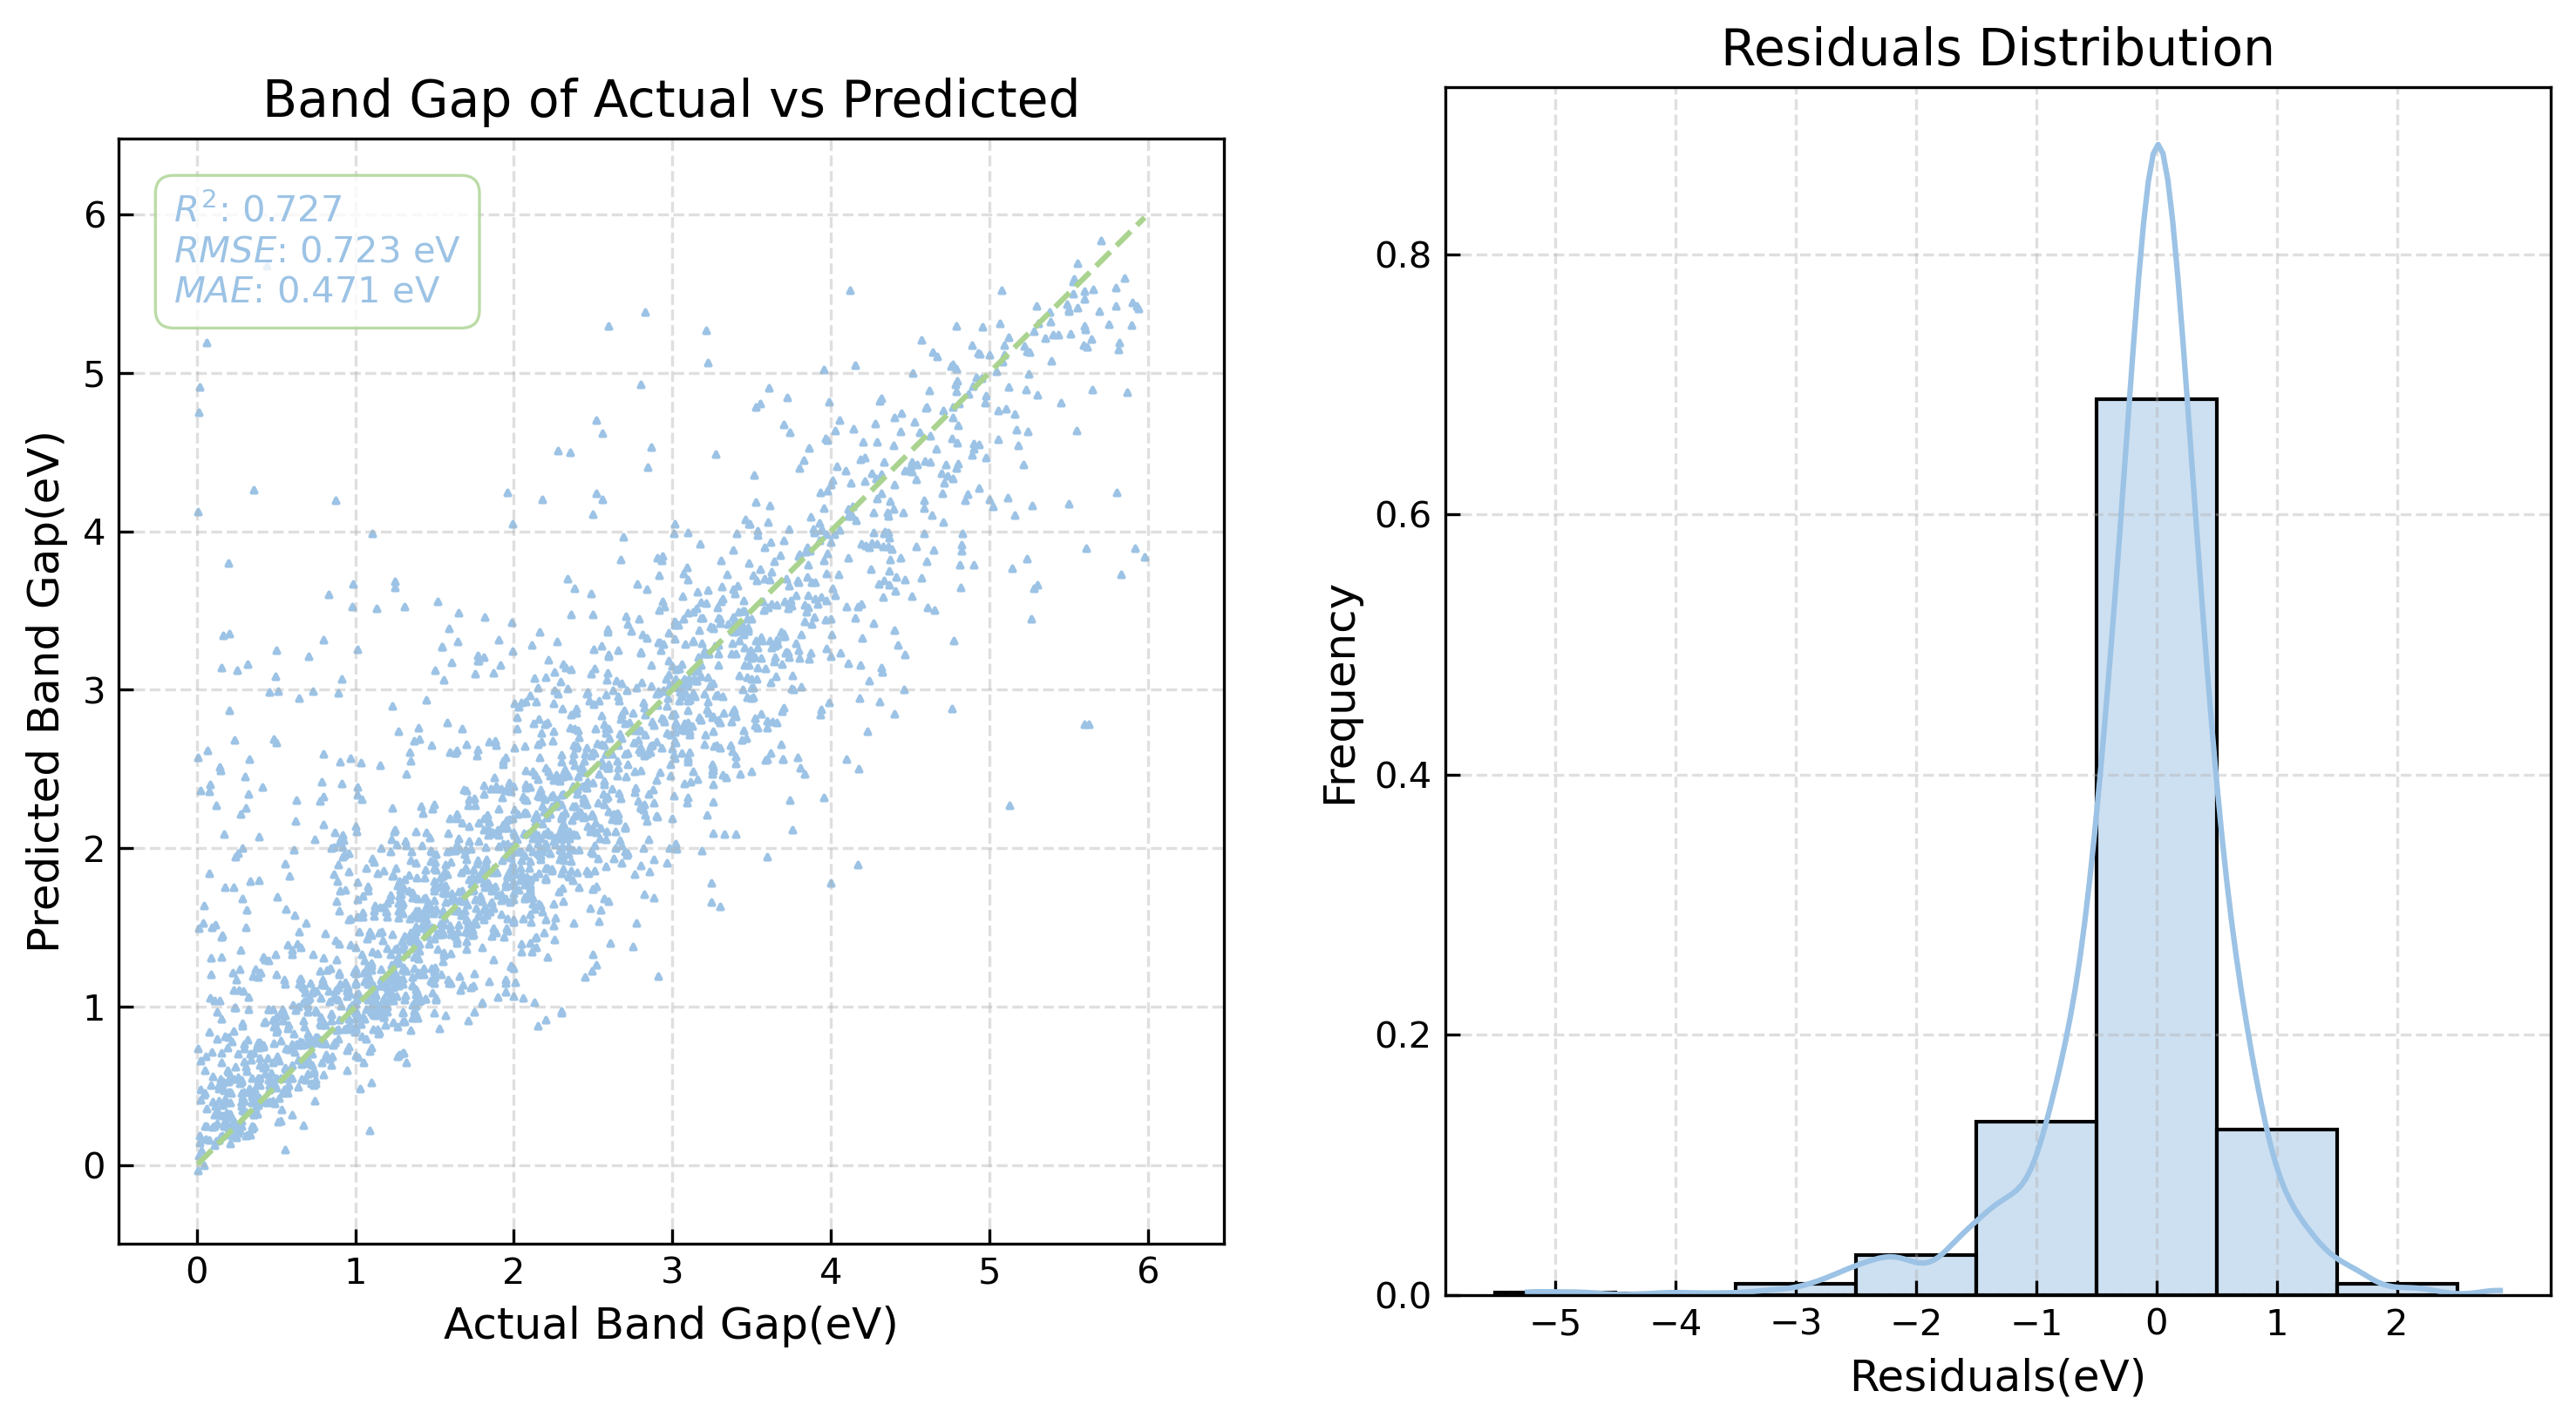


Model Evaluation Results:
Test set size: 2271
Test set: R²: 0.7266 RMSE: 0.7230 MAE: 0.4710 MAPE: 154.0061%


,Model,Error_Type,Train_set,Test_set,R²,RMSE,MAE
0,Self Learning XGBoost,Train,mix,mix,0.971521,0.228275,0.170405
1,Self Learning XGBoost,Test,mix,dft,0.685462,0.819339,0.538090
2,Self Learning XGBoost,Test,mix,exp,0.816929,0.518326,0.346339
3,Self Learning XGBoost,Test,mix,mix,0.726553,0.723009,0.470995


In [ ]:
# 
MODEL_NAME = 'Self Learning XGBoost'
# record model metrics
model_metrics = pd.DataFrame(columns=['Model', 'Error_Type', 'Train_set', 'Test_set', 'R²', 'RMSE', 'MAE'])
# Train the model on mixed data
print("#" * 100)
print(f"[DFT - {MODEL_NAME}] Training {MODEL_NAME} on Mix data:")
print("-" * 100)

model = eventually_model

# evaluate on the train set
print(f"[Train_error] Evaluating {MODEL_NAME} on train set:")
metrics = model.evaluate(train_X, train_y)
model_metrics.loc[len(model_metrics)] = {
'Model': MODEL_NAME,
'Error_Type': 'Train',
'Train_set': 'mix',
'Test_set': 'mix',
'R²': metrics['r2'],
'RMSE': metrics['rmse'],
'MAE': metrics['mae']
}

# evaluate on the dft test set
print(f"[Test MIX -> DFT] Evaluating {MODEL_NAME} on DFT test set:")

metrics = model.evaluate(dft_test_X, dft_test_y)
model_metrics.loc[len(model_metrics)] = {
'Model': MODEL_NAME,
'Error_Type': 'Test',
'Train_set': 'mix',
'Test_set': 'dft',
'R²': metrics['r2'],
'RMSE': metrics['rmse'],
'MAE': metrics['mae']
}
# evaluate on the exp test set
print(f"[Test MIX -> EXP] Evaluating {MODEL_NAME} on EXP test set:")
metrics = model.evaluate(exp_test_X, exp_test_y)
model_metrics.loc[len(model_metrics)] = {
'Model': MODEL_NAME,
'Error_Type': 'Test',
'Train_set': 'mix',
'Test_set': 'exp',
'R²': metrics['r2'],
'RMSE': metrics['rmse'],
'MAE': metrics['mae']
}

# evaluate on the mixed test set
print(f"[Test MIX -> MIX] Evaluating {MODEL_NAME} on mixed test set:")
metrics = model.evaluate(test_X, test_y)
model_metrics.loc[len(model_metrics)] = {
'Model': MODEL_NAME,    
'Error_Type': 'Test',
'Train_set': 'mix',
'Test_set': 'mix',
'R²': metrics['r2'],
'RMSE': metrics['rmse'],
'MAE': metrics['mae']
}
# save the model metrics to a csv file
model_metrics.to_csv(os.path.join(file_path, 'model_metrics.csv'), index=False)
model_metrics

**Compare to direct mix:**
- the self-learning model has a better performance on the **exp test set**, 
- but the performance on the dft test set is not as good as the direct mix model.

In [ ]:
# 2. sampled dft train data
self_learn_model = exp_model
eventually_model = None
# 
LARGE_ERROR = 1.1
EXP_RATIO = 0.5
# sample size of dft train data
SAMPLE_RATE = 0.5
# track
iteration_metrics = []  
rng = np.random.RandomState(RANDOM_SEED)
consecutive_no_improvement = 0

for i in range(100):
    # sample the dft train data
    iter_seed = rng.randint(0, 10000)
    sample_dft_train_X = dft_train_X.sample(frac=SAMPLE_RATE, random_state=iter_seed)
    sample_dft_train_y = dft_train_y.loc[sample_dft_train_X.index]

    # reset index
    sample_dft_train_X.reset_index(drop=True, inplace=True)
    sample_dft_train_y.reset_index(drop=True, inplace=True)
    
    pred_y = self_learn_model.predict(sample_dft_train_X)

    # discard the samples with large error
    # get the samples with small error  
    small_error_index = (np.abs(pred_y - sample_dft_train_y) <= LARGE_ERROR)
    small_error_X = sample_dft_train_X[small_error_index]
    # 
    small_error_y = (pred_y[small_error_index]*EXP_RATIO) + (sample_dft_train_y[small_error_index]*(1-EXP_RATIO))

    # log
    print(f'[ Iteration {i} ]: ')
    print(f'small error samples: {small_error_X.shape[0]}')
    # save metrics
    test_metrics = self_learn_model.evaluate(test_X, test_y, fig_show=False)
    iteration_metrics.append({
        'iteration': i,
        'small_error_samples': small_error_X.shape[0],
        'test_r2': test_metrics['r2'],
        'test_rmse': test_metrics['rmse']
    })

    # early stopping
    if i > 0 and iteration_metrics[-1]['test_rmse'] >= iteration_metrics[-2]['test_rmse']:
        consecutive_no_improvement += 1
    else:
        consecutive_no_improvement = 0

    if consecutive_no_improvement >= 3:
        print(f"Early stopping at iteration {i} due to no improvement")
        eventually_model = self_learn_model
        break

    # train the model on the small error samples and exp samples
    train_X = pd.concat([small_error_X, exp_train_X], axis=0, ignore_index=True)
    train_y = pd.concat([small_error_y, exp_train_y], axis=0, ignore_index=True)

    self_learn_model = SingleModel(clone(xgb), random_state=RANDOM_SEED)
    self_learn_model.train(train_X, train_y)

if eventually_model is None:
    eventually_model = self_learn_model


[ Iteration 0 ]: 
small error samples: 7404

Model Evaluation Results:
Test set size: 2271
Test set: R²: 0.4504 RMSE: 1.0250 MAE: 0.7125 MAPE: 208.4920%
Starting model training...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............. (step 2 of 2) Processing model, total=   1.8s
Model training completed!
[ Iteration 1 ]: 
small error samples: 8292

Model Evaluation Results:
Test set size: 2271
Test set: R²: 0.5709 RMSE: 0.9057 MAE: 0.6149 MAPE: 190.2720%
Starting model training...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............. (step 2 of 2) Processing model, total=   1.8s
Model training completed!
[ Iteration 2 ]: 
small error samples: 8753

Model Evaluation Results:
Test set size: 2271
Test set: R²: 0.6190 RMSE: 0.8534 MAE: 0.5696 MAPE: 181.2599%
Starting model training...
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............. (step 2 of 2) Processing mod

####################################################################################################
[DFT - Sample Self Learning XGBoost] Training Sample Self Learning XGBoost on Mix data:
----------------------------------------------------------------------------------------------------
[Train_error] Evaluating Sample Self Learning XGBoost on train set:


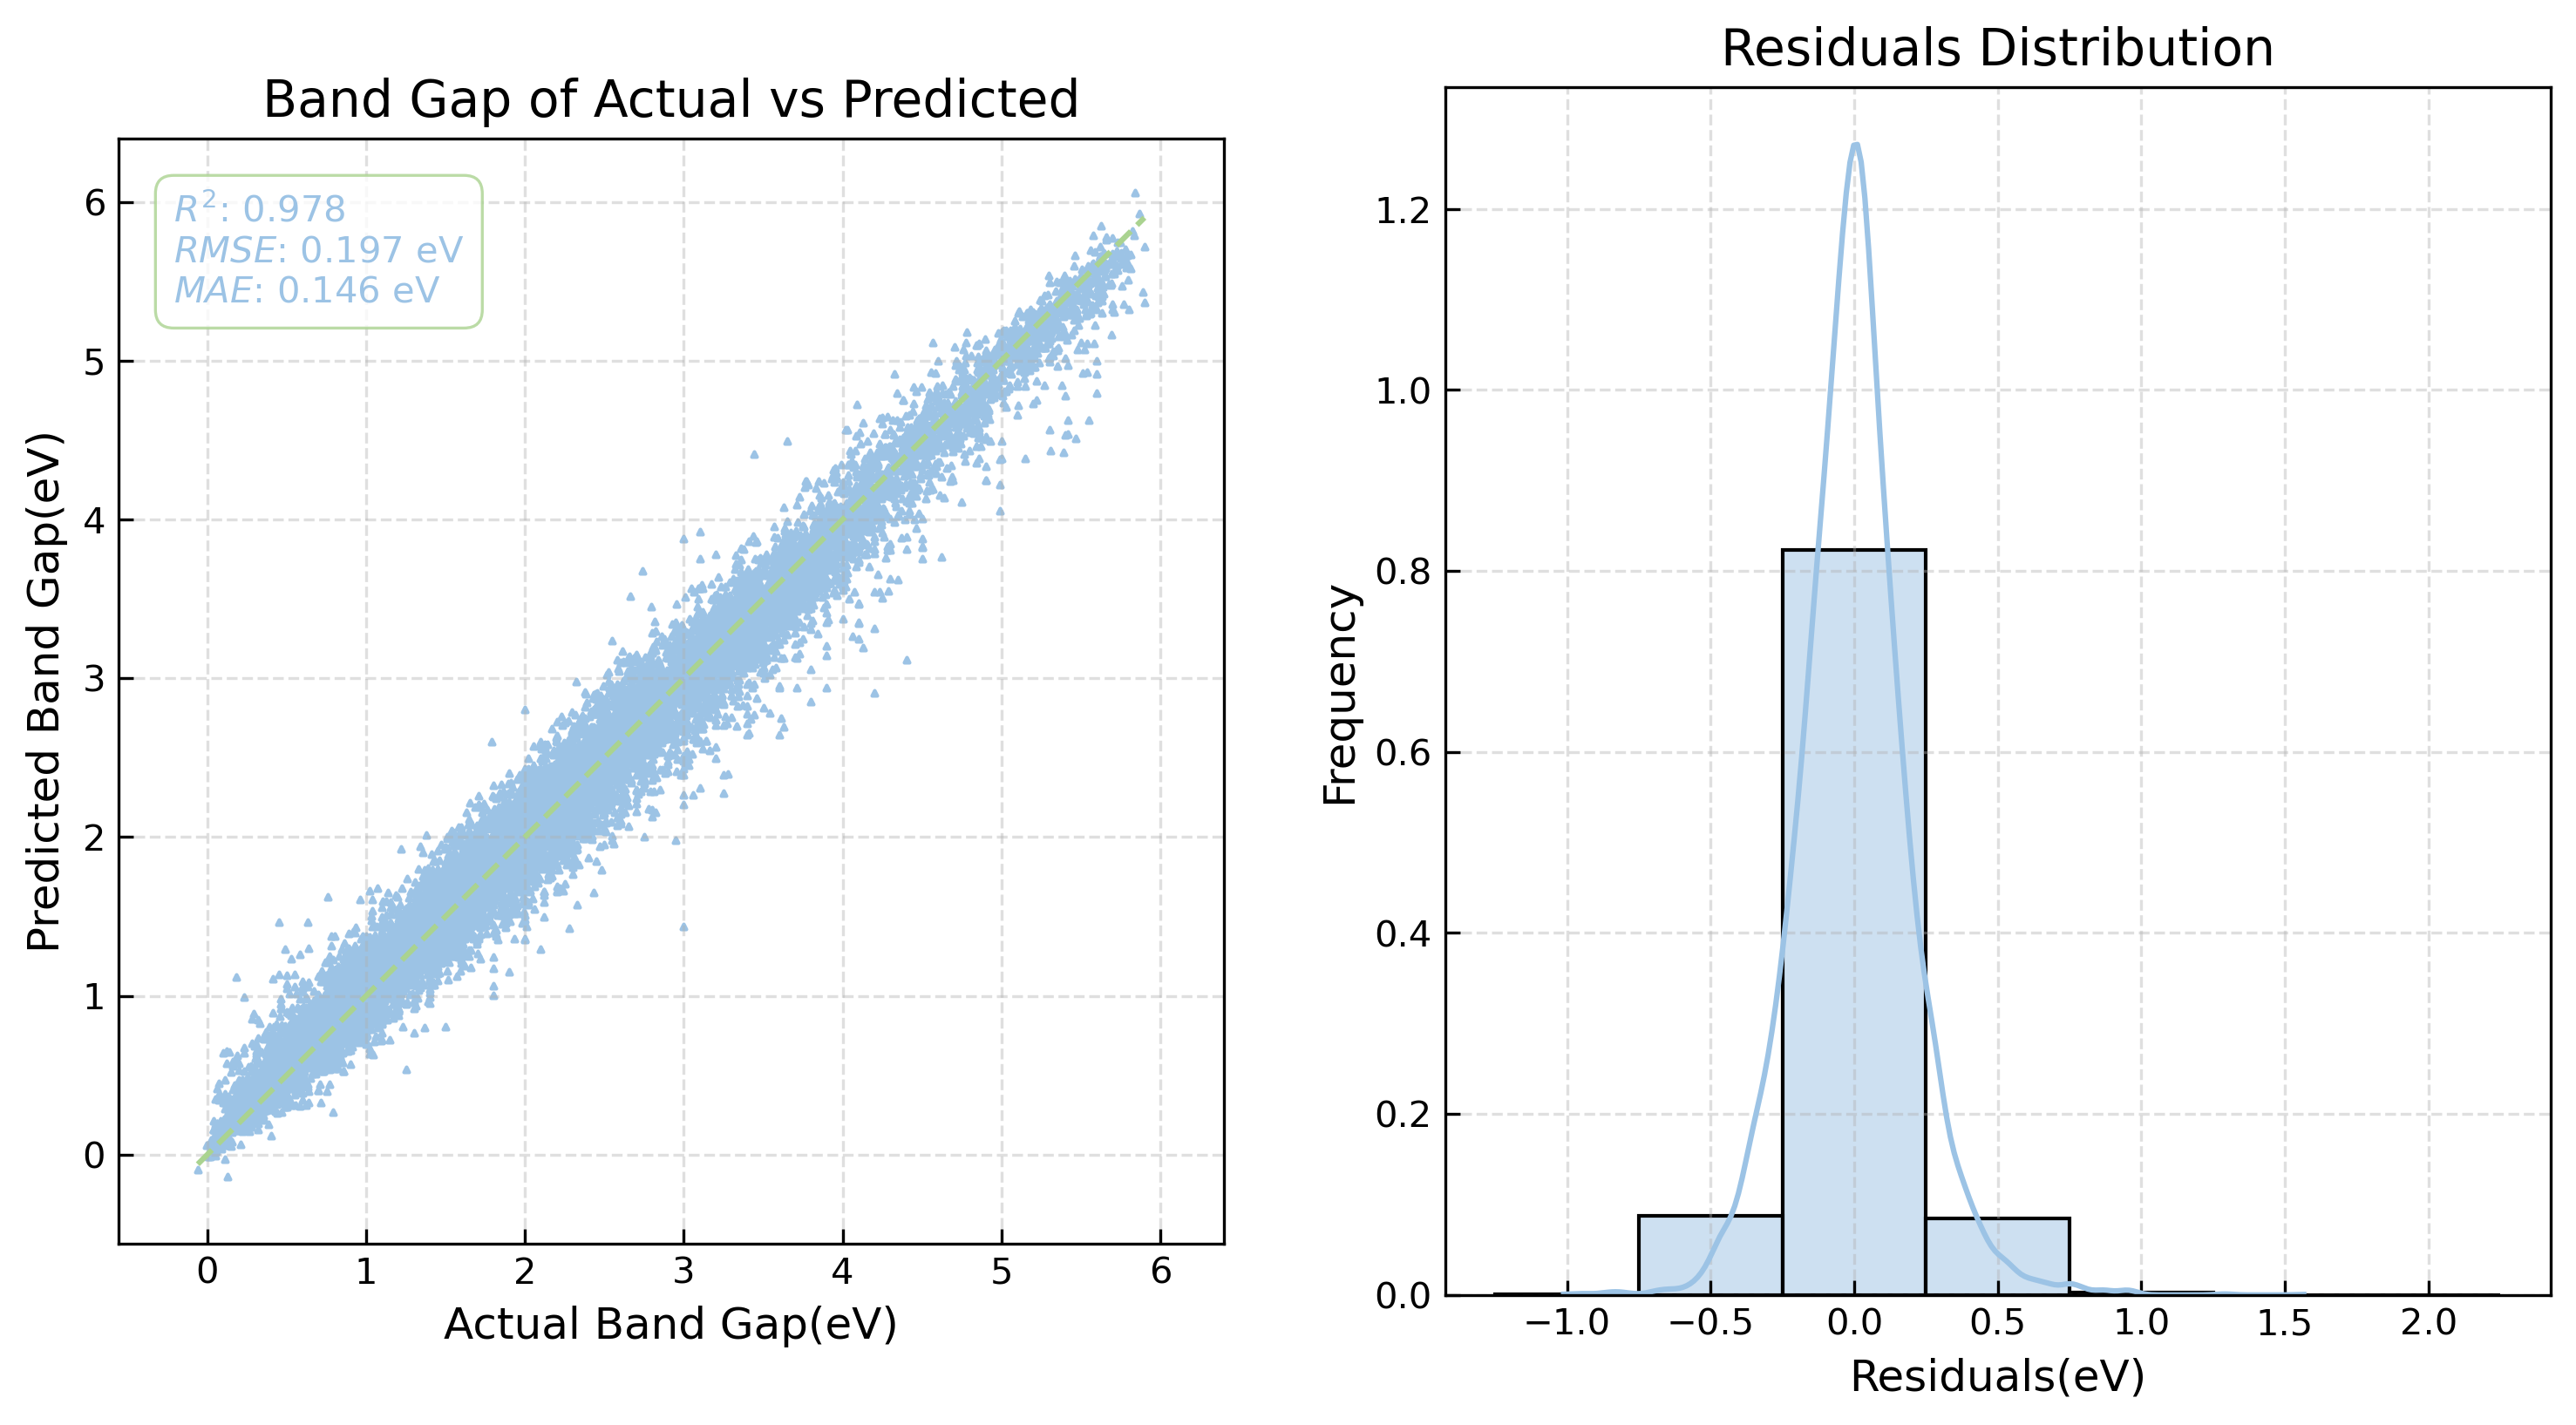


Model Evaluation Results:
Test set size: 12703
Test set: R²: 0.9781 RMSE: 0.1970 MAE: 0.1462 MAPE: 11.0391%
[Test MIX -> DFT] Evaluating Sample Self Learning XGBoost on DFT test set:


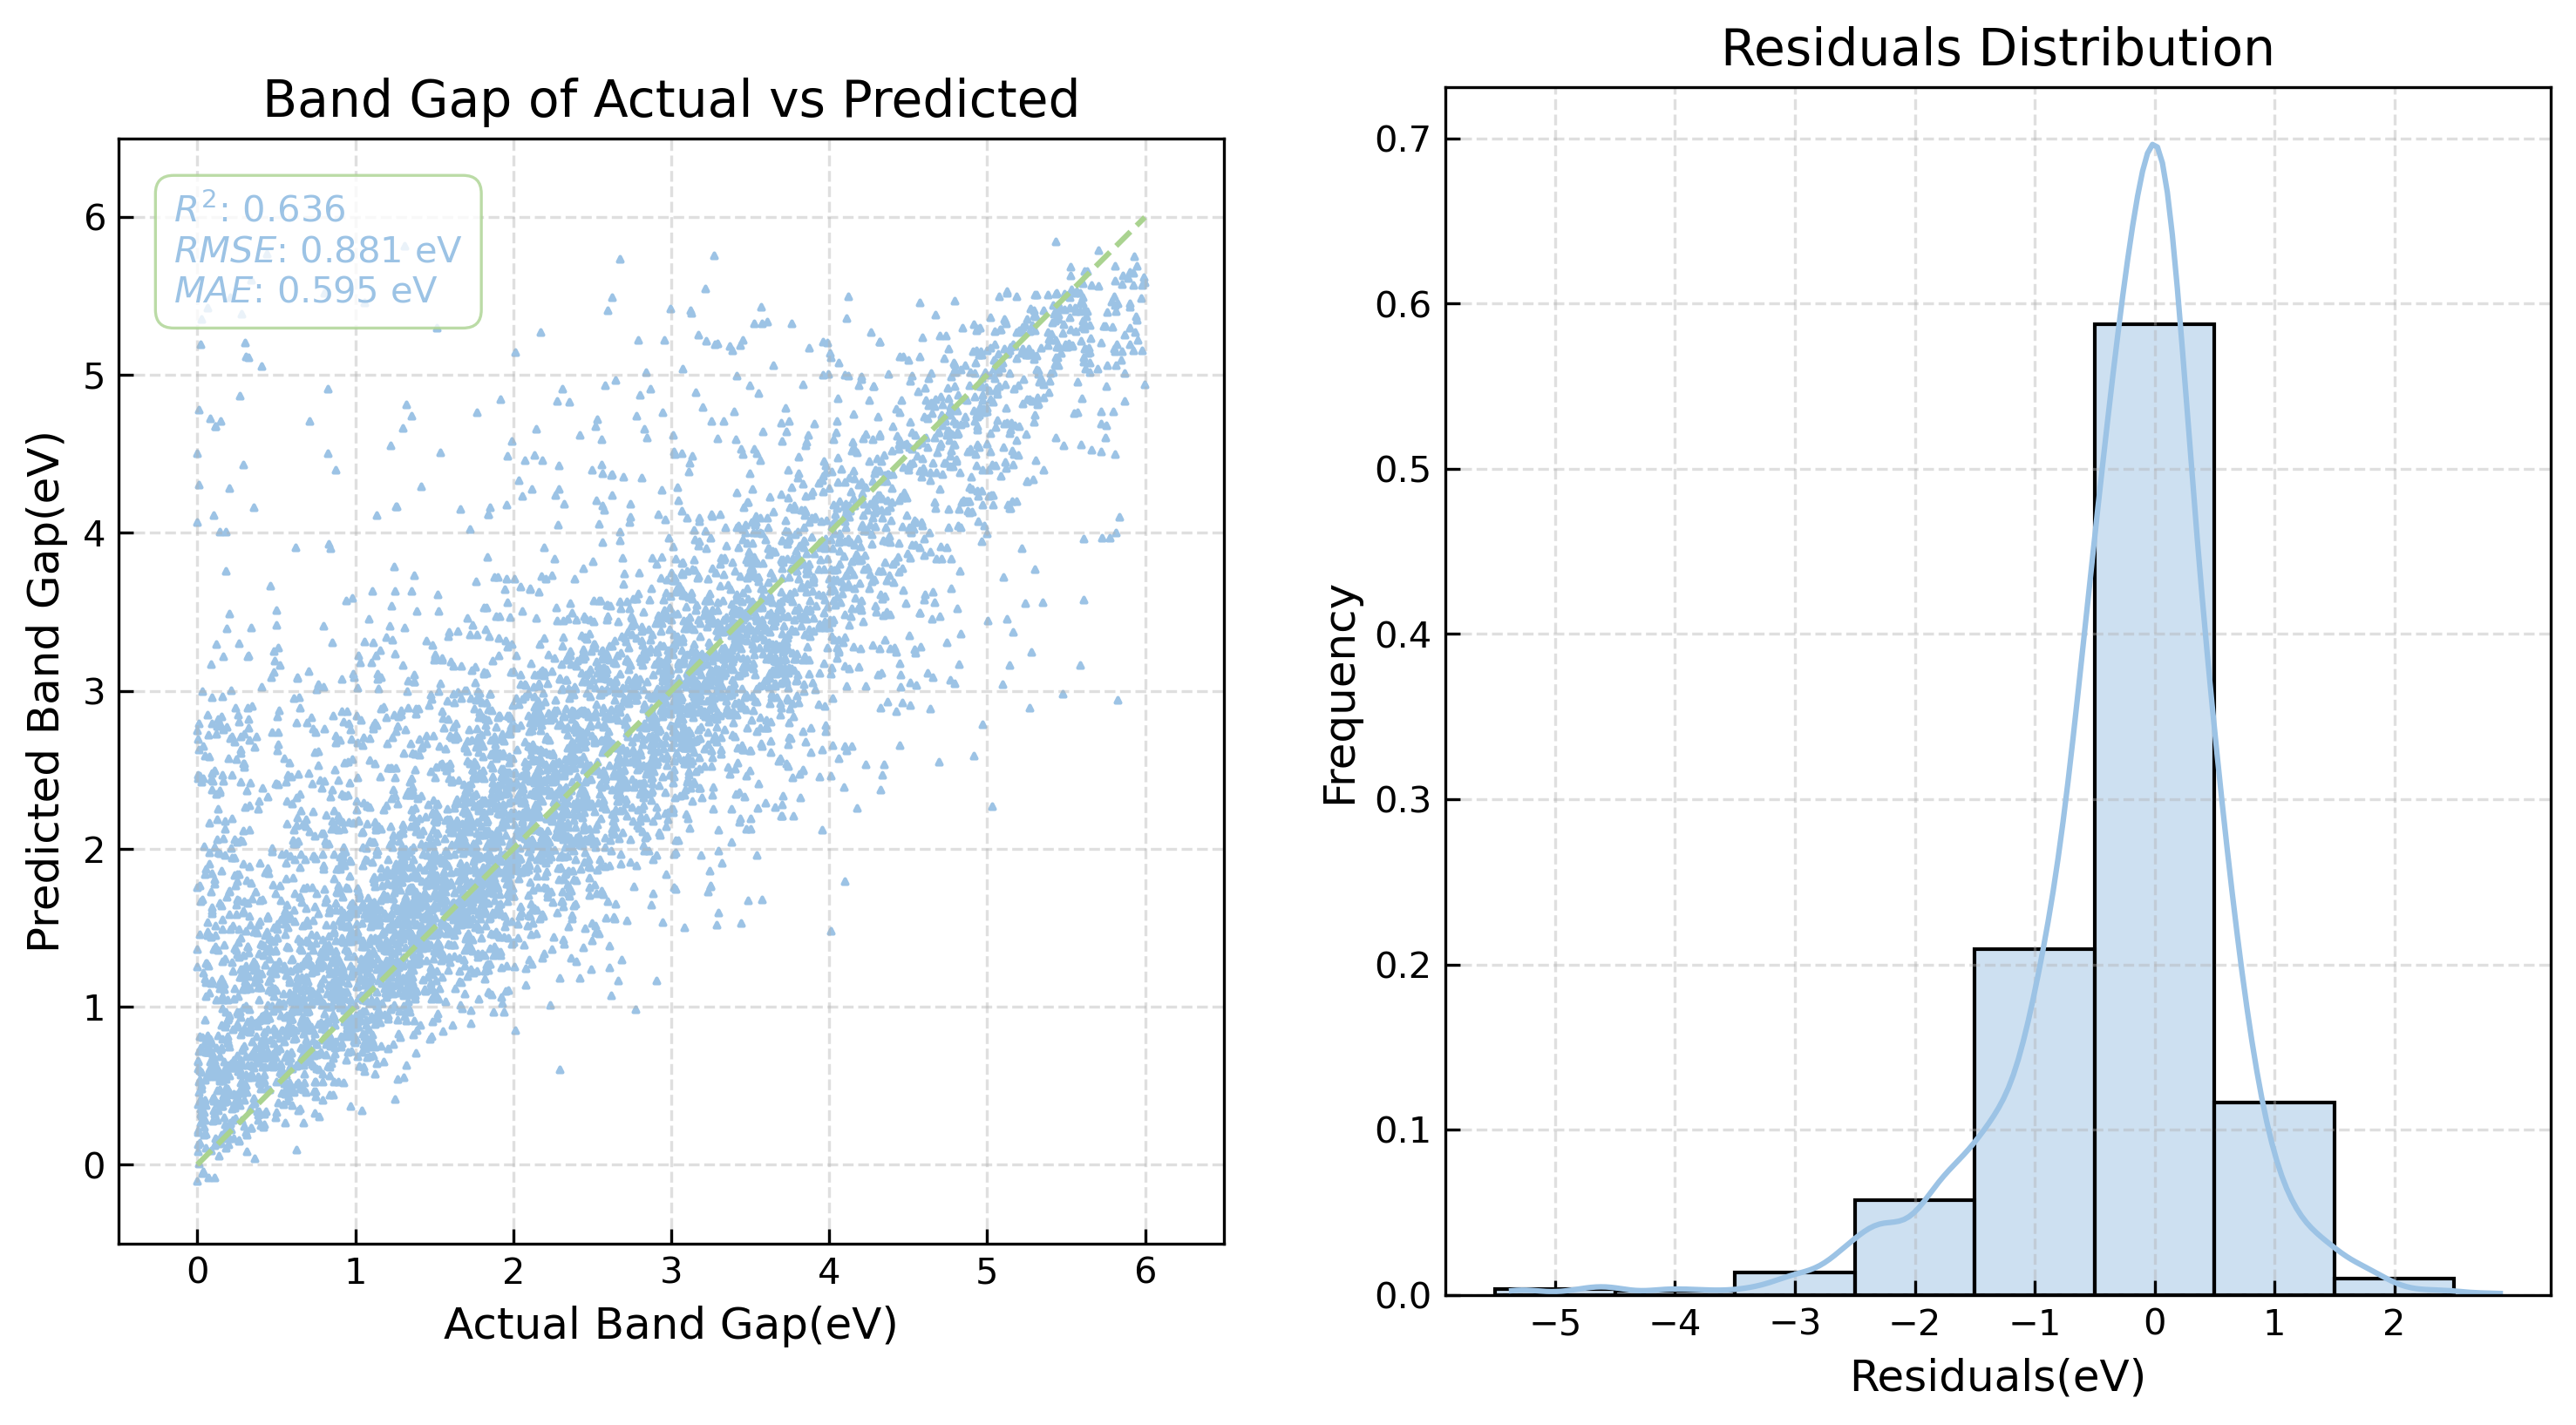


Model Evaluation Results:
Test set size: 5556
Test set: R²: 0.6360 RMSE: 0.8815 MAE: 0.5953 MAPE: 2131.1132%
[Test MIX -> EXP] Evaluating Sample Self Learning XGBoost on EXP test set:


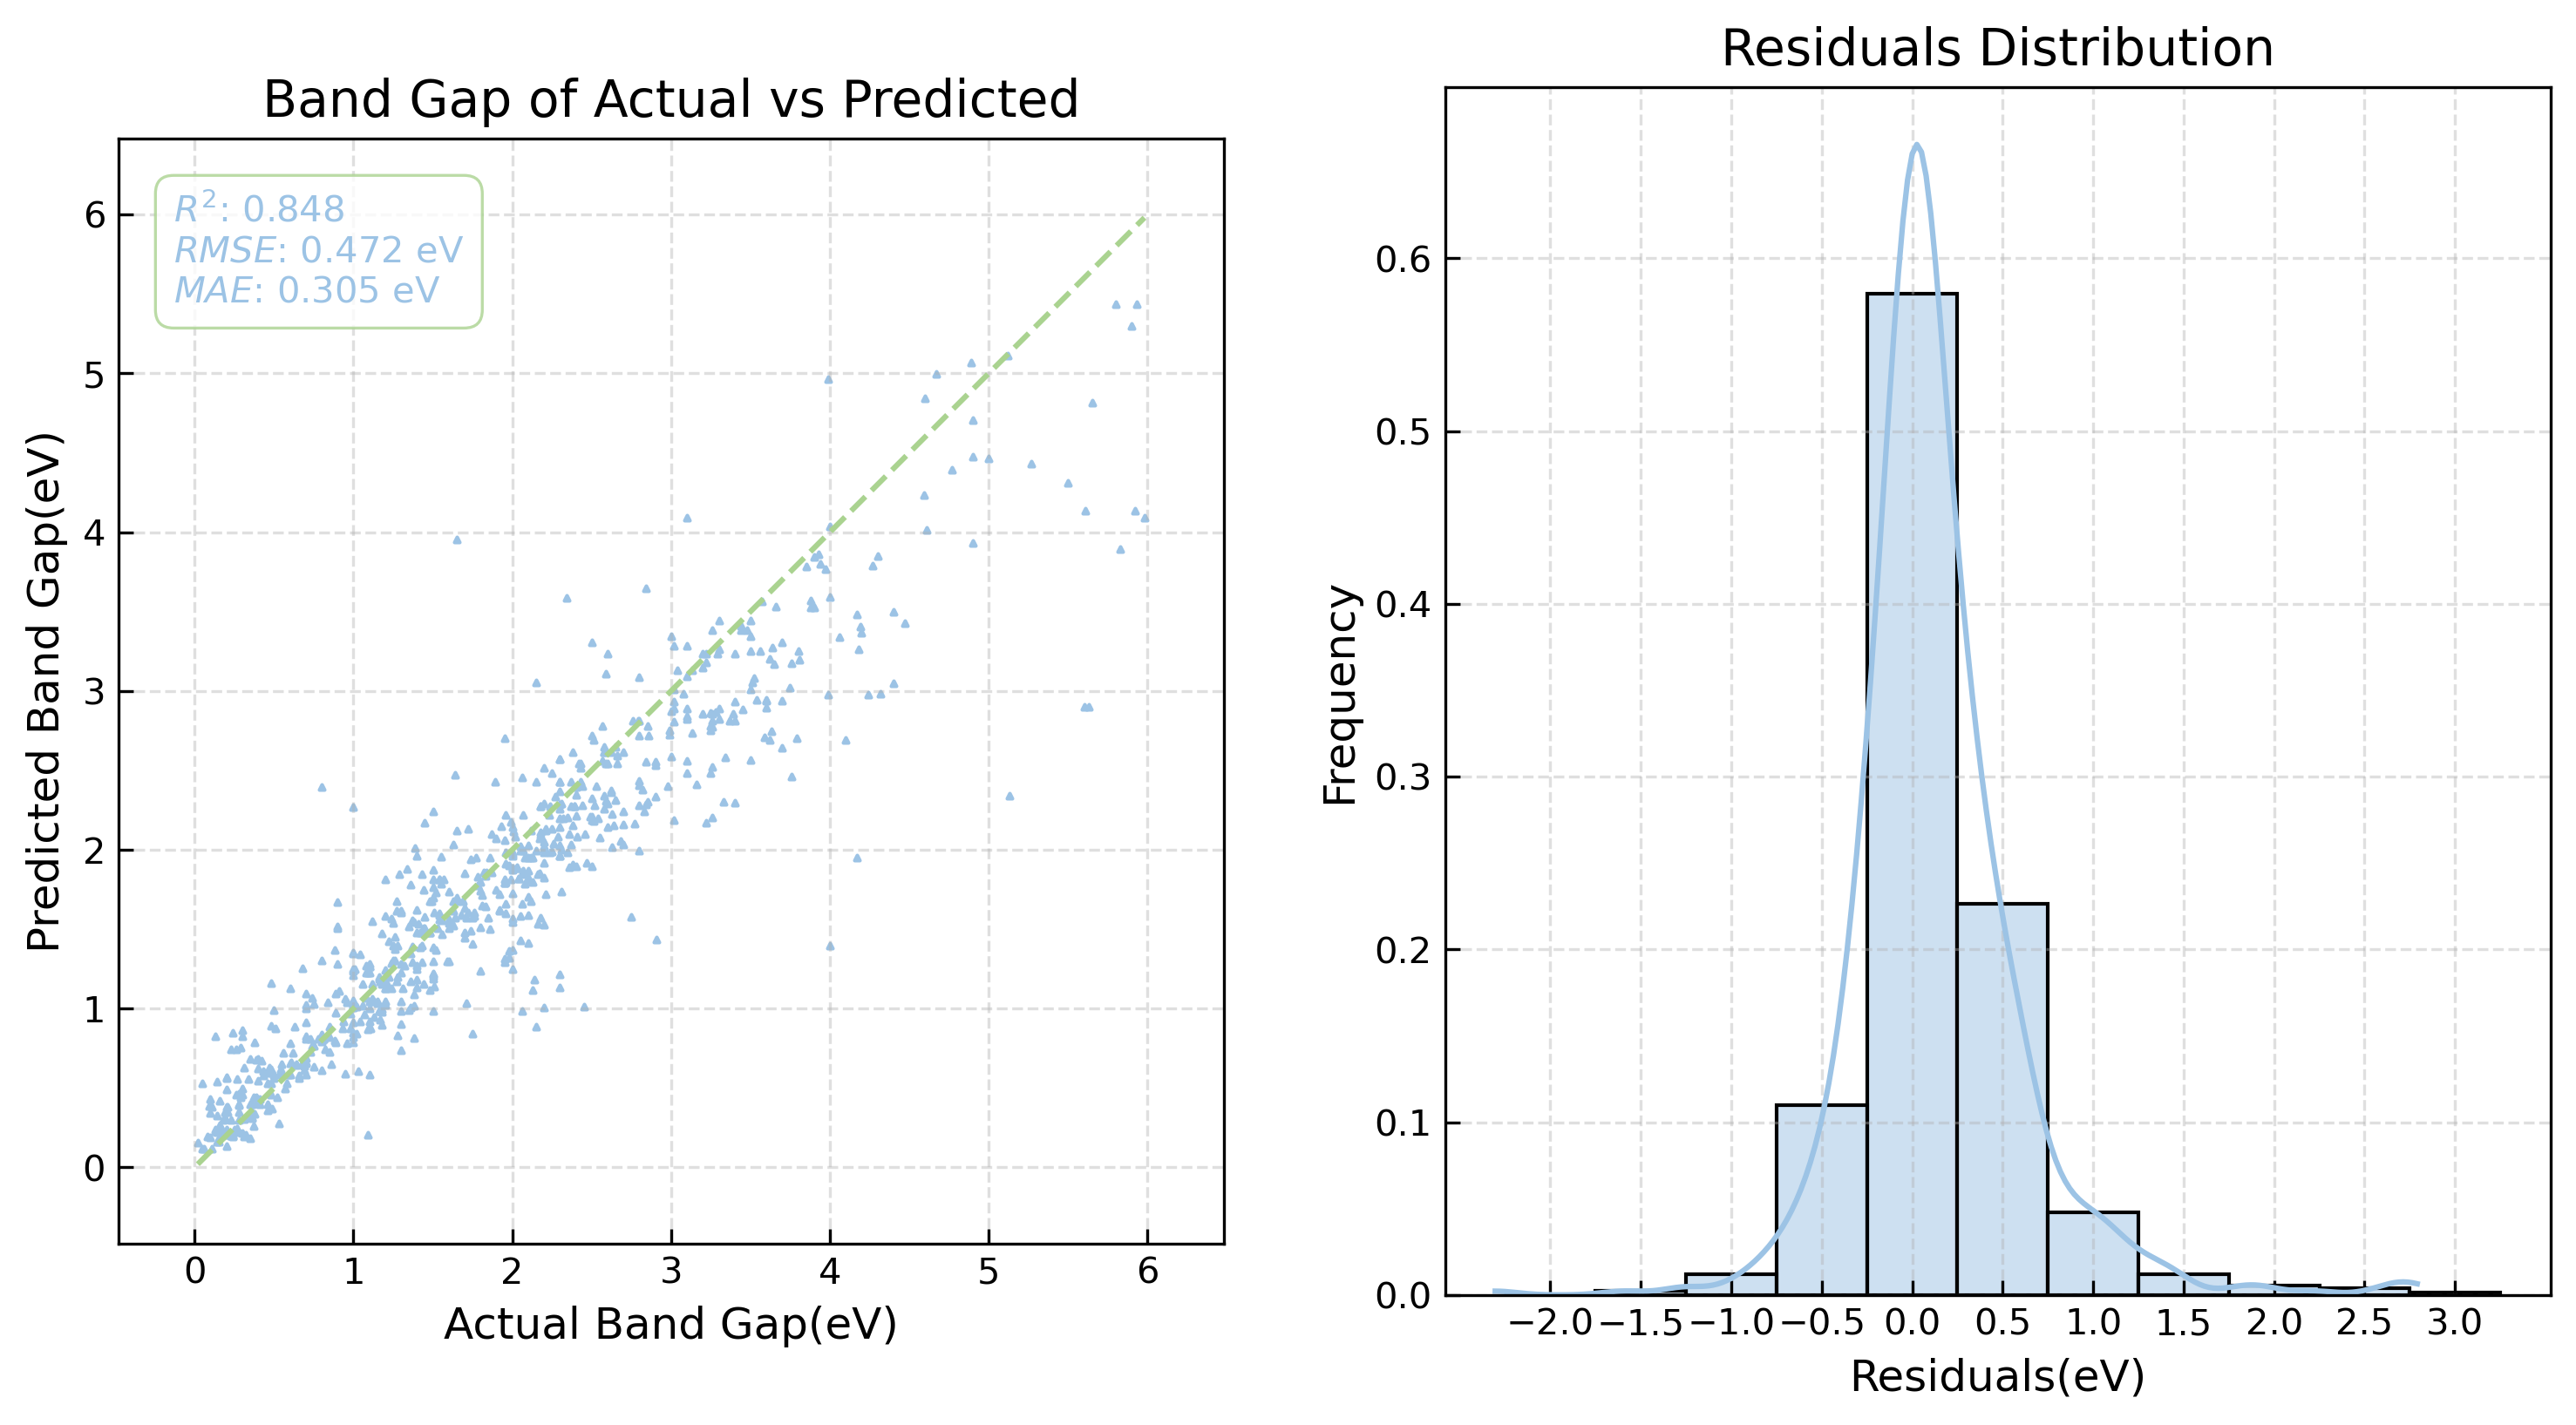


Model Evaluation Results:
Test set size: 757
Test set: R²: 0.8482 RMSE: 0.4720 MAE: 0.3047 MAPE: 25.8782%
[Test MIX -> MIX] Evaluating Sample Self Learning XGBoost on mixed test set:


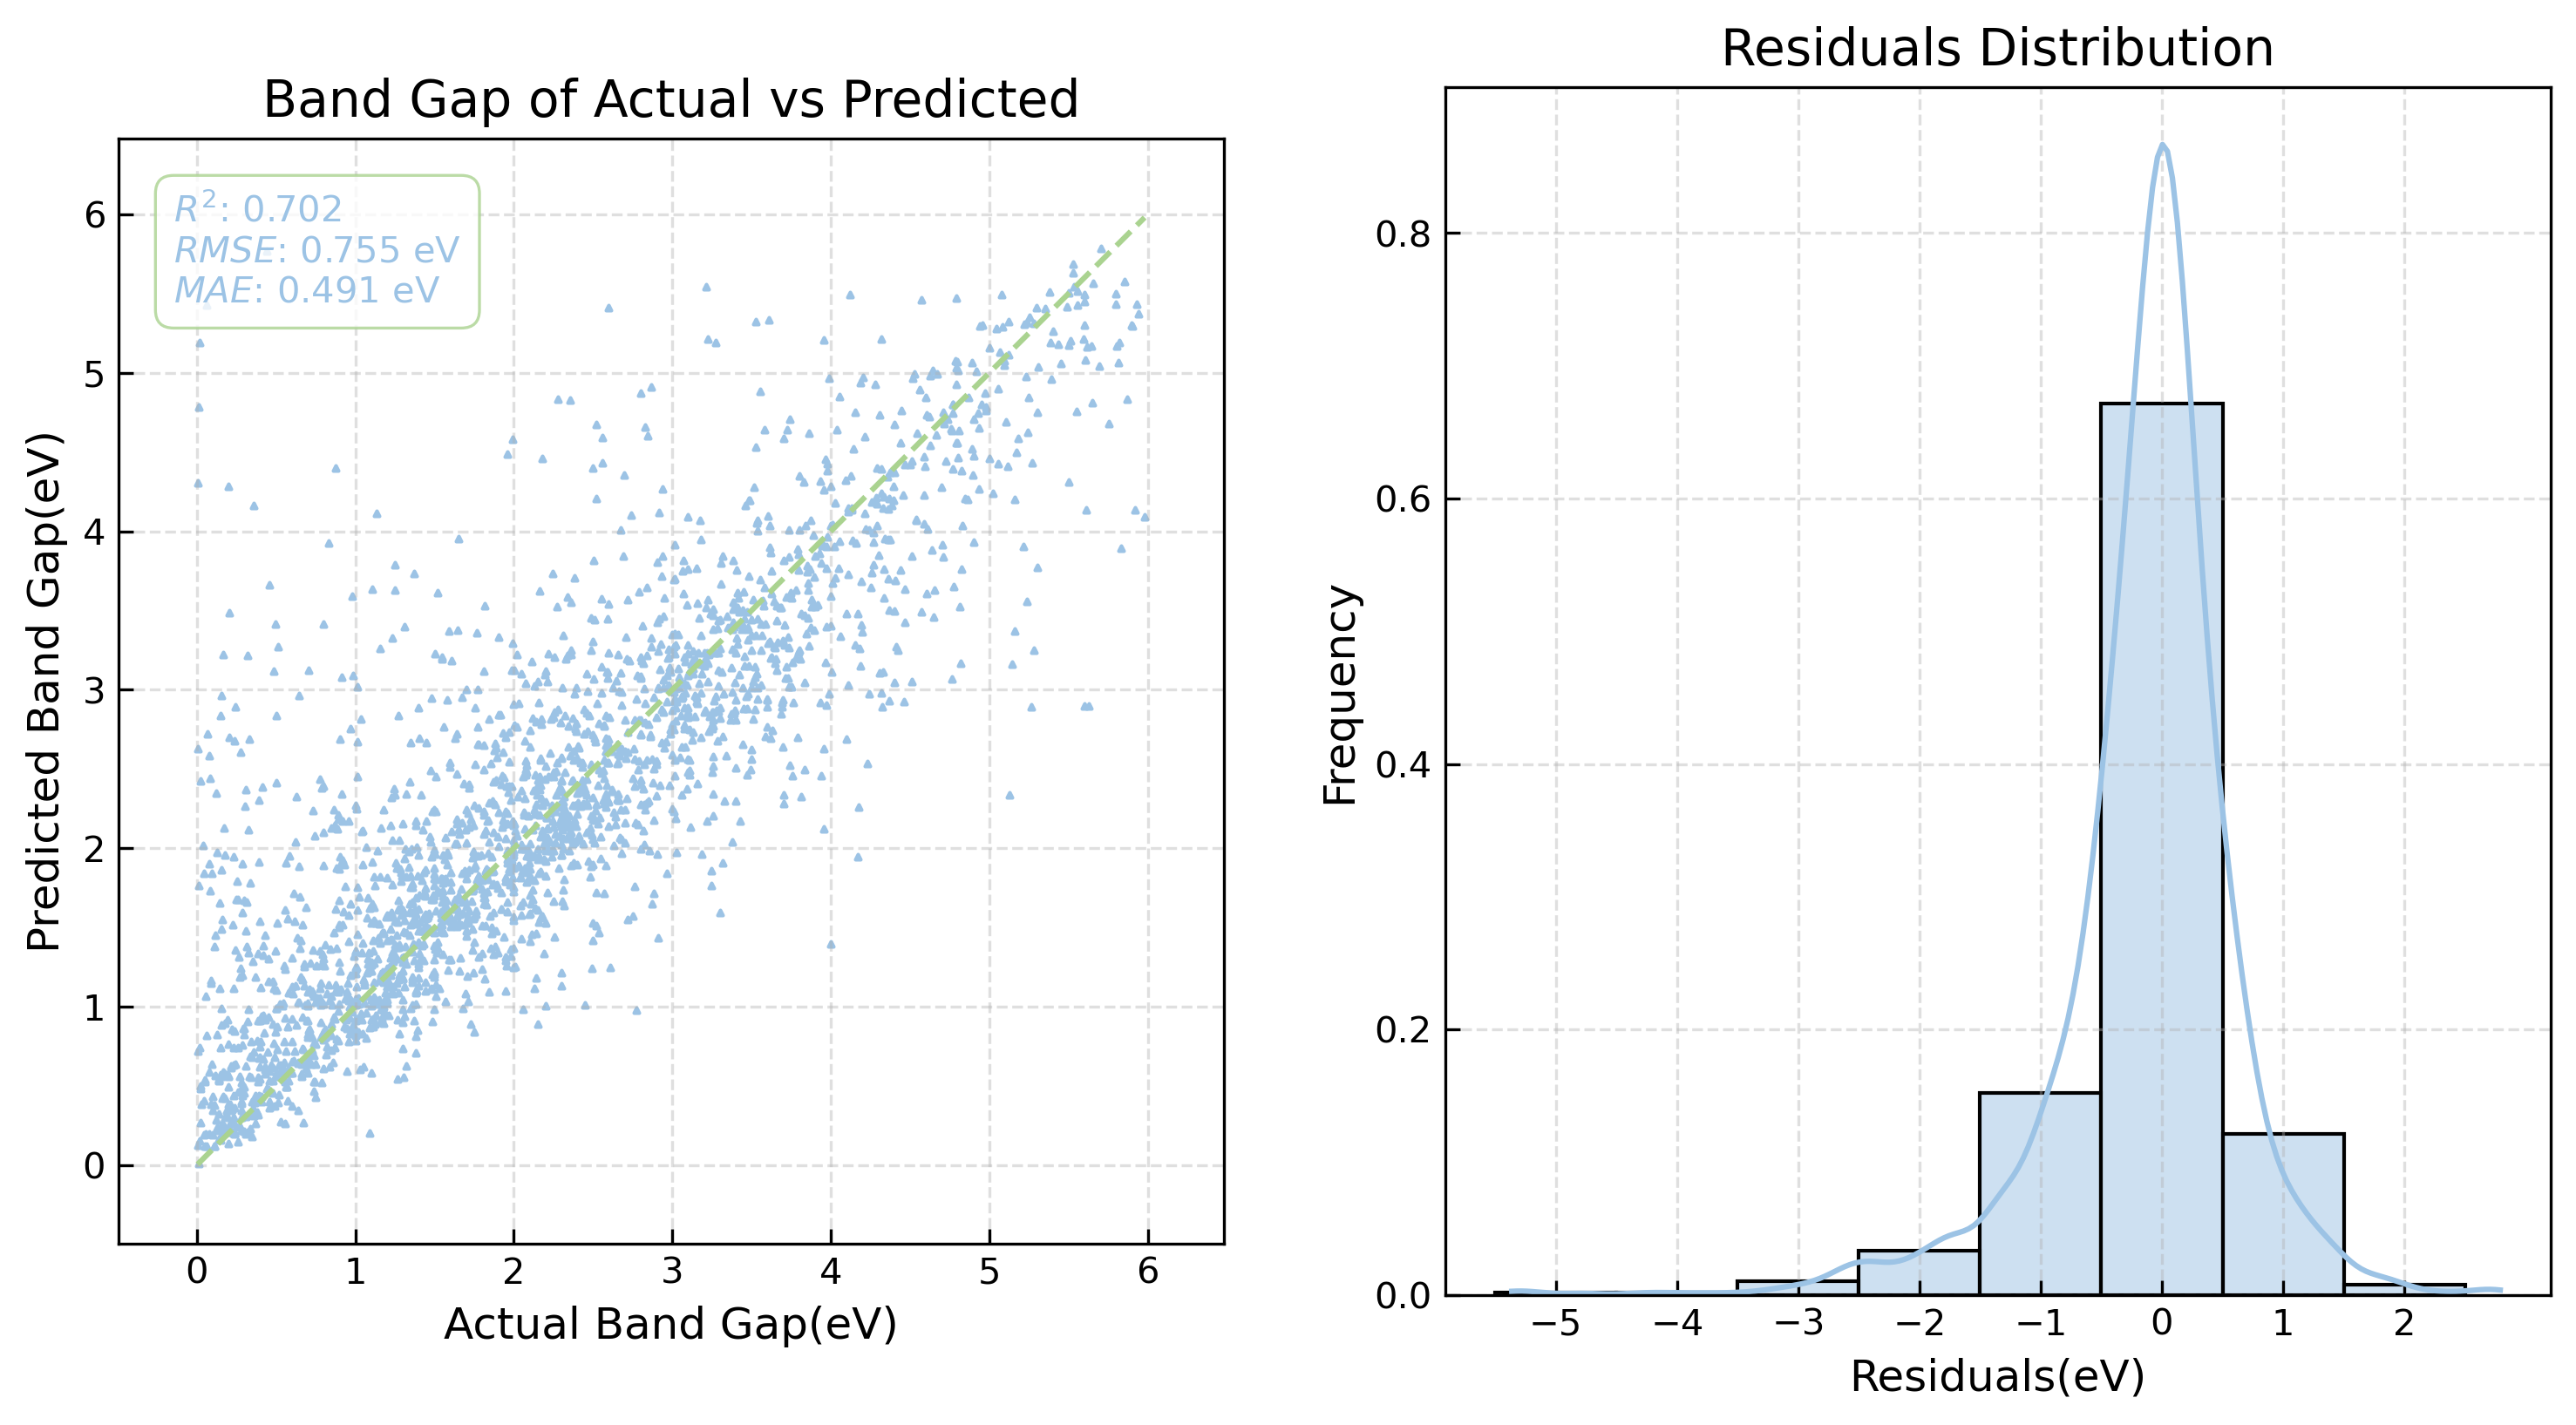


Model Evaluation Results:
Test set size: 2271
Test set: R²: 0.7021 RMSE: 0.7547 MAE: 0.4912 MAPE: 163.2829%


,Model,Error_Type,Train_set,Test_set,R²,RMSE,MAE
0,Sample Self Learning XGBoost,Train,mix,mix,0.978112,0.197002,0.146219
1,Sample Self Learning XGBoost,Test,mix,dft,0.635956,0.881462,0.595269
2,Sample Self Learning XGBoost,Test,mix,exp,0.848215,0.471963,0.304680
3,Sample Self Learning XGBoost,Test,mix,mix,0.702090,0.754657,0.491216


In [29]:
# 
MODEL_NAME = 'Sample Self Learning XGBoost'
# record model metrics
model_metrics = pd.DataFrame(columns=['Model', 'Error_Type', 'Train_set', 'Test_set', 'R²', 'RMSE', 'MAE'])
# Train the model on mixed data
print("#" * 100)
print(f"[DFT - {MODEL_NAME}] Training {MODEL_NAME} on Mix data:")
print("-" * 100)

model = eventually_model

# evaluate on the train set
print(f"[Train_error] Evaluating {MODEL_NAME} on train set:")
metrics = model.evaluate(train_X, train_y)
model_metrics.loc[len(model_metrics)] = {
'Model': MODEL_NAME,
'Error_Type': 'Train',
'Train_set': 'mix',
'Test_set': 'mix',
'R²': metrics['r2'],
'RMSE': metrics['rmse'],
'MAE': metrics['mae']
}

# evaluate on the dft test set
print(f"[Test MIX -> DFT] Evaluating {MODEL_NAME} on DFT test set:")

metrics = model.evaluate(dft_test_X, dft_test_y)
model_metrics.loc[len(model_metrics)] = {
'Model': MODEL_NAME,
'Error_Type': 'Test',
'Train_set': 'mix',
'Test_set': 'dft',
'R²': metrics['r2'],
'RMSE': metrics['rmse'],
'MAE': metrics['mae']
}
# evaluate on the exp test set
print(f"[Test MIX -> EXP] Evaluating {MODEL_NAME} on EXP test set:")
metrics = model.evaluate(exp_test_X, exp_test_y)
model_metrics.loc[len(model_metrics)] = {
'Model': MODEL_NAME,
'Error_Type': 'Test',
'Train_set': 'mix',
'Test_set': 'exp',
'R²': metrics['r2'],
'RMSE': metrics['rmse'],
'MAE': metrics['mae']
}

# evaluate on the mixed test set
print(f"[Test MIX -> MIX] Evaluating {MODEL_NAME} on mixed test set:")
metrics = model.evaluate(test_X, test_y)
model_metrics.loc[len(model_metrics)] = {
'Model': MODEL_NAME,    
'Error_Type': 'Test',
'Train_set': 'mix',
'Test_set': 'mix',
'R²': metrics['r2'],
'RMSE': metrics['rmse'],
'MAE': metrics['mae']
}
# save the model metrics to a csv file
# model_metrics.to_csv(os.path.join(file_path, 'model_metrics.csv'), index=False)
model_metrics

- Sampled dft train data model is not good as the total dft train data model.